
# Multi-Pollutant Multi-Horizon Air Quality Classification



In [25]:
# ======================================================
# Cell 1: Environment Setup and Library Imports
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import json
import time
import warnings
import os
from collections import defaultdict
from itertools import product
from joblib import Parallel, delayed, parallel_backend
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit, PredefinedSplit
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             cohen_kappa_score, matthews_corrcoef, brier_score_loss)
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.impute import SimpleImputer
from sklearn.exceptions import ConvergenceWarning
from sklearn.utils import resample
from scipy import stats
warnings.filterwarnings('ignore', category=ConvergenceWarning)

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available. Install with: pip install xgboost")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
N_JOBS = min(8, os.cpu_count())

N_CORES = os.cpu_count()


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 120)

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = None
for candidate in [NOTEBOOK_DIR, NOTEBOOK_DIR.parent, NOTEBOOK_DIR.parent.parent]:
    if (candidate / 'clean_data' / 'airquality_prepared').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not locate project root containing clean_data/airquality_prepared')

BASE_DIR = PROJECT_ROOT / 'clean_data' / 'airquality_prepared'
OUTPUT_BASE = PROJECT_ROOT / 'classification-model' / 'outputs'
FIGURES_DIR = OUTPUT_BASE / 'figures'
PERFORMANCE_DIR = FIGURES_DIR / 'performance'
DIAGNOSTICS_DIR = FIGURES_DIR / 'diagnostics'
for directory in [OUTPUT_BASE, FIGURES_DIR, PERFORMANCE_DIR, DIAGNOSTICS_DIR, OUTPUT_BASE / 'results']:
    directory.mkdir(parents=True, exist_ok=True)

sys.path.append(str(BASE_DIR))
from loader import load_pack

# Data Splitting Strategy (Year-Based Temporal Split)



```
Train:  2004 data (March - October)      → 5,622 samples (60.2%)
Val:    2004 data (November - December)  → 1,464 samples (15.7%)
Test:   2005 data (January - April)      → 2,247 samples (24.1%)
Total:  9,333 samples
```



In [26]:

# ======================================================
# Cell 2: Data Loading and Pollutant Identification
# ======================================================

PACK_DIR = BASE_DIR
cleaned_path = PACK_DIR / 'cleaned.parquet'
df_clean = pd.read_parquet(cleaned_path)

POLLUTANTS = [col for col in df_clean.columns
              if '(GT)' in col and '__' not in col]
ACTIVE_POLLUTANTS = [p for p in POLLUTANTS if df_clean[p].nunique() > 1]
print(f" Identified {len(ACTIVE_POLLUTANTS)} active pollutants")

X_tr, yreg_tr, ycls_tr = load_pack(str(PACK_DIR), pack='trees', split='train')
X_va, yreg_va, ycls_va = load_pack(str(PACK_DIR), pack='trees', split='val')
X_te, yreg_te, ycls_te = load_pack(str(PACK_DIR), pack='trees', split='test')
print(f"X_tr shape: {X_tr.shape}")

with open(PACK_DIR / 'splits.json', 'r') as f:
    splits = json.load(f)
idx_train = np.array(splits['train'])
idx_val = np.array(splits['val'])
idx_test = np.array(splits['test'])

with open(PACK_DIR / 'artifacts.json', 'r') as f:
    artifacts = json.load(f)
MIN_LAG = max(artifacts['lags'])
print(f" MIN_LAG = {MIN_LAG}")


 Identified 4 active pollutants
X_tr shape: (6525, 185)
 MIN_LAG = 24


In [ ]:
# ======================================================
# Cell 3.5: Data Quality Checks and Distribution Analysis
# ======================================================

print("=" * 80)
print("Data Quality Checks")
print("=" * 80)

# 1. Missing value analysis
print("\n1. Missing Value Analysis:")
missing_rate = df_clean.isnull().sum() / len(df_clean)
high_missing = missing_rate[missing_rate > 0.1]
if len(high_missing) > 0:
    print(f"   Columns with >10% missing values: {len(high_missing)}")
    print(high_missing.sort_values(ascending=False).head(10))
else:
    print("   No columns with >10% missing values")

# 2. Outlier detection using Z-score
print("\n2. Outlier Detection (Z-score > 3):")
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
outlier_counts = {}
for col in numeric_cols[:10]:  # Check first 10 numeric columns
    if df_clean[col].notna().sum() > 100:
        z_scores = np.abs(stats.zscore(df_clean[col].dropna()))
        outliers = (z_scores > 3).sum()
        if outliers > 0:
            outlier_counts[col] = outliers
if outlier_counts:
    print(f"   Found outliers in {len(outlier_counts)} columns")
    for col, count in sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"   {col}: {count} outliers")
else:
    print("   No significant outliers detected (Z-score > 3)")

# 3. Time series continuity check
print("\n3. Time Series Continuity:")
if 'timestamp' in df_clean.columns:
    time_gaps = df_clean['timestamp'].diff()
    large_gaps = time_gaps[time_gaps > pd.Timedelta(hours=2)]
    print(f"   Large time gaps (>2 hours): {len(large_gaps)}")
    if len(large_gaps) > 0:
        print(f"   Largest gap: {large_gaps.max()}")

# 4. Distribution shift check between train and test
print("\n4. Distribution Shift Check (Train vs Test):")
if len(numeric_cols) > 0:
    shift_detected = []
    for col in numeric_cols[:5]:  # Check first 5 columns
        if col in X_tr.columns and col in X_te.columns:
            train_vals = X_tr[col].dropna()
            test_vals = X_te[col].dropna()
            if len(train_vals) > 100 and len(test_vals) > 100:
                stat, p_value = stats.ks_2samp(train_vals, test_vals)
                if p_value < 0.05:
                    shift_detected.append((col, p_value))
    if shift_detected:
        print(f"   Distribution shift detected in {len(shift_detected)} features (p<0.05)")
        for col, p_val in shift_detected[:3]:
            print(f"   {col}: p={p_val:.4f}")
    else:
        print("   No significant distribution shift detected")



Data Quality Checks

1. Missing Value Analysis:
   No columns with >10% missing values

2. Outlier Detection (Z-score > 3):
   Found outliers in 9 columns
   NOx(GT): 253 outliers
   CO(GT): 165 outliers
   C6H6(GT): 135 outliers
   PT08.S3(NOx): 123 outliers
   NO2(GT): 84 outliers

3. Time Series Continuity:
   Large time gaps (>2 hours): 0

4. Distribution Shift Check (Train vs Test):
   Distribution shift detected in 2 features (p<0.05)
   CO(GT): p=0.0000
   C6H6(GT): p=0.0000

Data Quality Checks Complete

Note: Class distribution analysis will be performed after classification targets are constructed (Cell 7).


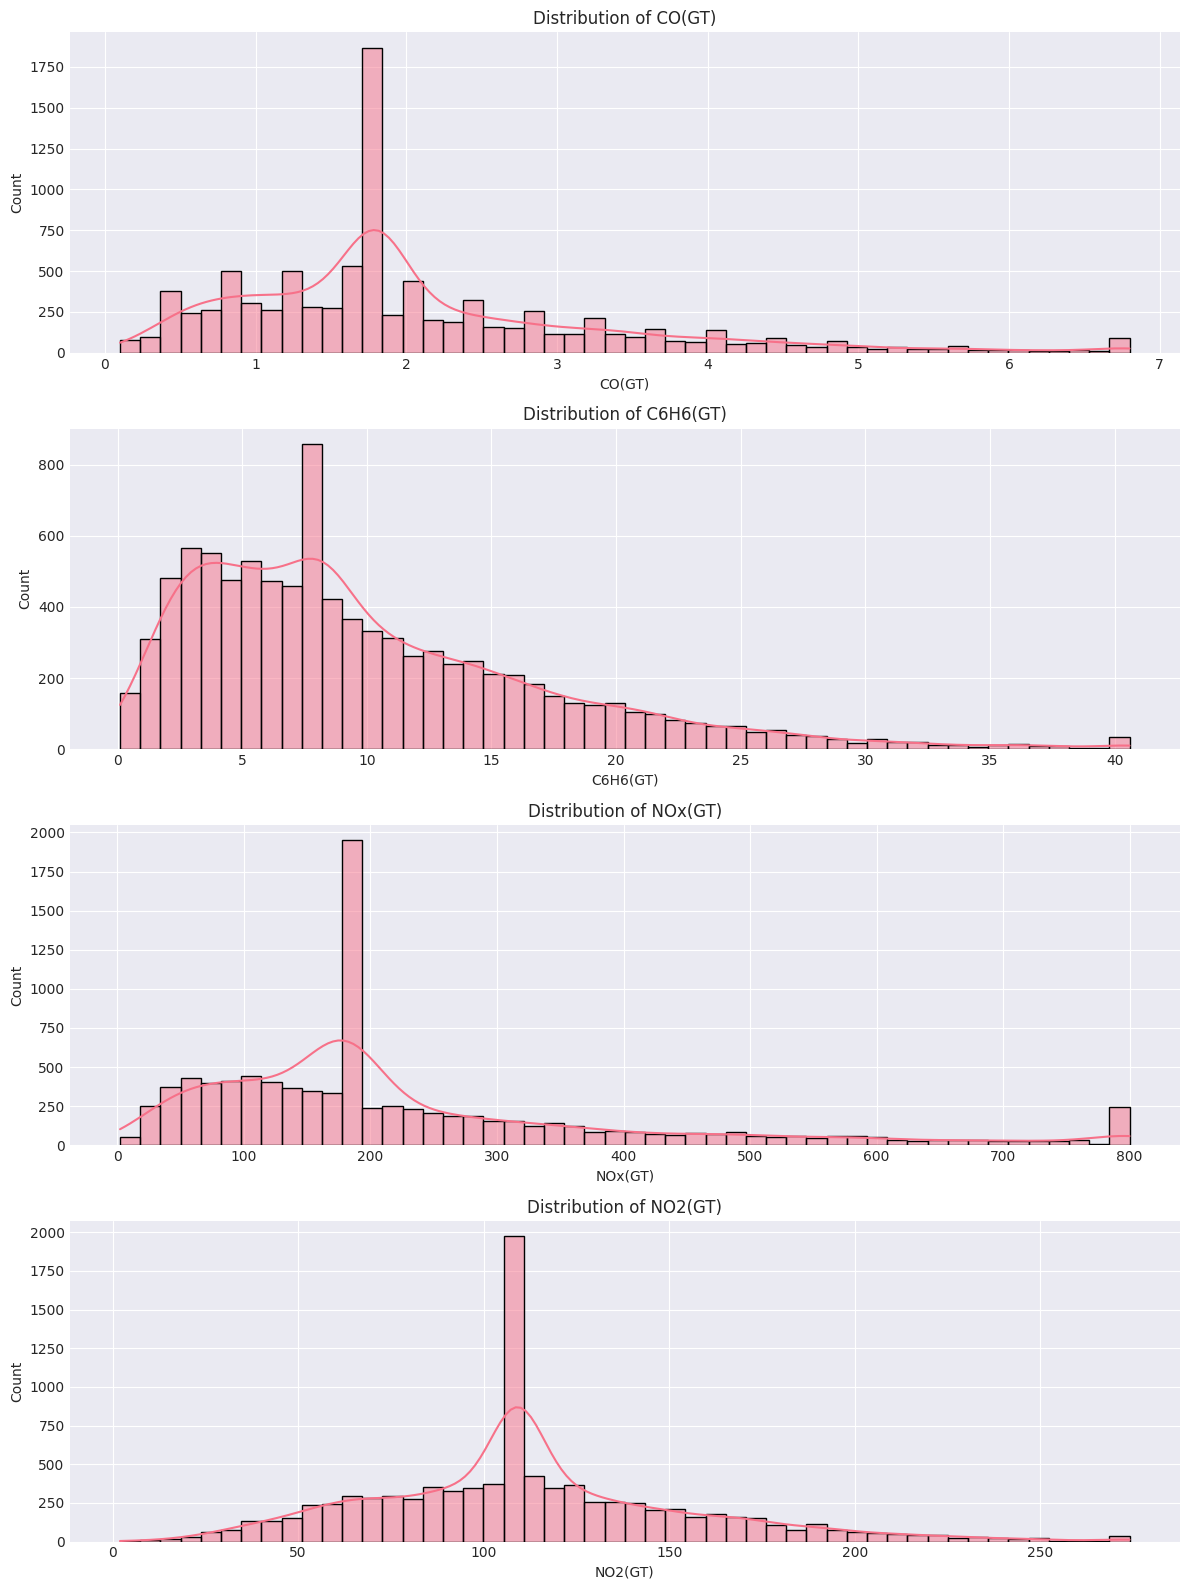

 Saved distribution plots to outputs/figures/performance/pollutant_distributions.png


In [28]:

# ======================================================
# Cell 3: Exploratory Data Analysis (Pollutant Distributions)
# ======================================================

fig, axes = plt.subplots(len(ACTIVE_POLLUTANTS), 1, figsize=(12, 4 * len(ACTIVE_POLLUTANTS)))
if len(ACTIVE_POLLUTANTS) == 1:
    axes = [axes]
for ax, pollutant in zip(axes, ACTIVE_POLLUTANTS):
    sns.histplot(df_clean[pollutant].dropna(), bins=50, ax=ax, kde=True)
    ax.set_title(f'Distribution of {pollutant}')
plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'figures'  /'performance'/'pollutant_distributions.png', dpi=300)
plt.show()
print(' Saved distribution plots to outputs/figures/performance/pollutant_distributions.png')


In [29]:
# ======================================================
# Cell 5.5: Feature Selection Utilities
# ======================================================


def select_features(X_train, y_train, X_val, y_val, method='mutual_info', k=100):
    """
    Select top k features using various methods.
    """
    if method == 'mutual_info':
        selector = SelectKBest(score_func=mutual_info_classif, k=min(k, X_train.shape[1]))
        selector.fit(X_train, y_train)
        selected_features = X_train.columns[selector.get_support()].tolist()
        return selected_features, selector

    if method == 'f_classif':
        selector = SelectKBest(score_func=f_classif, k=min(k, X_train.shape[1]))
        selector.fit(X_train, y_train)
        selected_features = X_train.columns[selector.get_support()].tolist()
        return selected_features, selector

    if method == 'rfe':
        base_estimator = RandomForestClassifier(
            n_estimators=50,
            random_state=RANDOM_STATE,
            class_weight='balanced',
            n_jobs=N_JOBS
        )
        selector = RFE(
            estimator=base_estimator,
            n_features_to_select=min(k, X_train.shape[1]),
            step=max(1, X_train.shape[1] // 20)
        )
        selector.fit(X_train, y_train)
        selected_features = X_train.columns[selector.get_support()].tolist()
        return selected_features, selector

    raise ValueError(f"Unknown method: {method}")


def apply_feature_selection(X_train, X_val, X_test, selected_features):
    """Apply feature selection to train/val/test splits."""
    X_train_selected = X_train[selected_features].copy()
    X_val_selected = X_val[selected_features].copy()
    X_test_selected = X_test[selected_features].copy()
    return X_train_selected, X_val_selected, X_test_selected


USE_FEATURE_SELECTION = True
FEATURE_SELECTION_METHOD = 'mutual_info'
N_SELECTED_FEATURES = 100
USE_HORIZON_SPECIFIC_FEATURES = True

HORIZON_LONG_LAGS = {
    24: [48, 72, 168]
}
HORIZON_ROLLING_WINDOWS = {
    24: [48, 96, 168]
}
MIN_LONG_FEATURE_VALID_RATIO = 0.2

USE_CLASS_REBALANCING = True
REBALANCE_TARGET_RATIO = 0.65
REBALANCE_STRATEGY = 'match_max'


def add_horizon_specific_features(X_data, horizon, df_clean=None, split_indices=None, context='train'):
    """Inject additional temporal/seasonal features for specific horizons."""
    if not USE_HORIZON_SPECIFIC_FEATURES:
        return X_data

    X_enhanced = X_data.copy()
    added_columns = []

    if df_clean is None or split_indices is None:
        return X_enhanced

    base_indices = np.asarray(split_indices, dtype=int) + MIN_LAG
    valid_base = (base_indices >= 0) & (base_indices < len(df_clean))
    if not np.any(valid_base):
        return X_enhanced

    co_series = df_clean['CO(GT)'].to_numpy() if 'CO(GT)' in df_clean.columns else None
    timestamp_series = df_clean['timestamp'] if 'timestamp' in df_clean.columns else None

    if horizon in HORIZON_LONG_LAGS and co_series is not None:
        for long_lag in HORIZON_LONG_LAGS[horizon]:
            feature_name = f'CO(GT)__lag{long_lag}'
            if feature_name in X_enhanced.columns:
                continue
            lag_idx = base_indices - long_lag
            values = np.full(len(X_enhanced), np.nan)
            valid_idx = (lag_idx >= 0) & (lag_idx < len(co_series))
            if np.any(valid_idx):
                values[valid_idx] = co_series[lag_idx[valid_idx]]
                X_enhanced[feature_name] = values
                added_columns.append(feature_name)

    if horizon in HORIZON_ROLLING_WINDOWS and co_series is not None:
        co_series_pd = pd.Series(co_series)
        for window in HORIZON_ROLLING_WINDOWS[horizon]:
            feature_name = f'CO(GT)__rollmean{window}'
            if feature_name in X_enhanced.columns:
                continue
            roll_series = co_series_pd.rolling(window=window, min_periods=max(12, window // 2)).mean().to_numpy()
            values = np.full(len(X_enhanced), np.nan)
            valid_idx = (base_indices >= 0) & (base_indices < len(roll_series))
            if np.any(valid_idx):
                values[valid_idx] = roll_series[base_indices[valid_idx]]
                X_enhanced[feature_name] = values
                added_columns.append(feature_name)

    if timestamp_series is not None:
        timestamps = timestamp_series.iloc[base_indices].reset_index(drop=True)
        if hasattr(timestamps, 'dt'):
            if 'day_of_year' not in X_enhanced.columns:
                X_enhanced['day_of_year'] = timestamps.dt.dayofyear
                X_enhanced['day_of_year_sin'] = np.sin(2 * np.pi * X_enhanced['day_of_year'] / 365.25)
                X_enhanced['day_of_year_cos'] = np.cos(2 * np.pi * X_enhanced['day_of_year'] / 365.25)
                added_columns.extend(['day_of_year', 'day_of_year_sin', 'day_of_year_cos'])
            if 'week_of_year' not in X_enhanced.columns:
                week_of_year = timestamps.dt.isocalendar().week.astype(int)
                X_enhanced['week_of_year'] = week_of_year
                X_enhanced['week_of_year_sin'] = np.sin(2 * np.pi * week_of_year / 52)
                X_enhanced['week_of_year_cos'] = np.cos(2 * np.pi * week_of_year / 52)
                added_columns.extend(['week_of_year', 'week_of_year_sin', 'week_of_year_cos'])

    if horizon == 1 and 'CO(GT)__lag1' in X_enhanced.columns and 'CO(GT)__lag2' in X_enhanced.columns:
        feature_name = 'CO_short_term_trend'
        if feature_name not in X_enhanced.columns:
            X_enhanced[feature_name] = X_enhanced['CO(GT)__lag1'] - X_enhanced['CO(GT)__lag2']
            added_columns.append(feature_name)

    for col in added_columns:
        if col in X_enhanced.columns and X_enhanced[col].isna().any():
            X_enhanced[col] = (
                X_enhanced[col]
                .fillna(method='ffill')
                .fillna(method='bfill')
                .fillna(0)
            )

    if added_columns and context == 'train':
        print(f"  [{horizon}h] Added horizon-specific features: {added_columns}")

    return X_enhanced


def rebalance_training_data(
    X_train,
    y_train,
    strategy='match_max',
    target_ratio=0.65,
    random_state=RANDOM_STATE
):
    """Oversample minority classes to alleviate imbalance."""
    summary = {
        'applied': False,
        'before': pd.Series(y_train).value_counts().sort_index().to_dict()
    }

    unique_labels = np.unique(y_train)
    if len(unique_labels) < 2:
        summary['after'] = summary['before']
        summary['ratio'] = 1.0
        return X_train, y_train, summary

    min_count = min(summary['before'].values())
    max_count = max(summary['before'].values())
    ratio = min_count / max_count if max_count > 0 else 1.0
    summary['ratio'] = ratio

    if ratio >= target_ratio:
        summary['after'] = summary['before']
        return X_train, y_train, summary

    target_size = max_count
    temp_df = X_train.copy().reset_index(drop=True)
    temp_df['__target__'] = y_train

    balanced_parts = []
    for cls_value, group in temp_df.groupby('__target__'):
        if len(group) < target_size:
            group_bal = resample(
                group,
                replace=True,
                n_samples=target_size,
                random_state=random_state
            )
        else:
            group_bal = group.copy()
        balanced_parts.append(group_bal)

    balanced_df = pd.concat(balanced_parts).sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    y_balanced = balanced_df.pop('__target__').to_numpy()

    summary['applied'] = True
    summary['after'] = pd.Series(y_balanced).value_counts().sort_index().to_dict()

    return balanced_df, y_balanced, summary


print("Feature selection utilities loaded.")
print(f"Feature selection enabled: {USE_FEATURE_SELECTION}")
if USE_FEATURE_SELECTION:
    print(f"Method: {FEATURE_SELECTION_METHOD}, Top {N_SELECTED_FEATURES} features")
print(f"Horizon-specific features enabled: {USE_HORIZON_SPECIFIC_FEATURES}")
print(f"Class rebalancing enabled: {USE_CLASS_REBALANCING} (target ratio ≥ {REBALANCE_TARGET_RATIO:.2f})")


Feature selection utilities loaded.
Feature selection enabled: True
Method: mutual_info, Top 100 features
Horizon-specific features enabled: True
Class rebalancing enabled: True (target ratio ≥ 0.65)


In [ ]:
# ======================================================
# Cell 6.5: Enhanced Feature Engineering
# ======================================================

# Perform enhanced feature engineering in the notebook, including:
# 1. Interaction features (ratios and products of pollutants)
# 2. Difference features (rate of change, trends)
# 3. Cyclical encoding (sin/cos transform)
# 4. Horizon-specific features for different prediction horizons

print('=' * 80)
print('Enhanced Feature Engineering')
print('=' * 80)


def create_enhanced_features(X_base, df_clean=None, horizon=None):
    """
    Create enhanced features based on loaded features or cleaned.parquet

    Args:
        X_base: Base features DataFrame (X loaded from load_pack)
        df_clean: DataFrame of cleaned.parquet (optional, used to create new features)
        horizon: Forecast horizon (1, 6, 12, 24), used for horizon-specific features

    Returns:
        X_enhanced: DataFrame with enhanced features
    """
    X_enhanced = X_base.copy()
    new_features_count = 0

    # Get base pollutant column names (remove __lag, __roll suffixes)
    base_pollutants = ['CO(GT)', 'NO2(GT)', 'NOx(GT)', 'C6H6(GT)', 'NMHC(GT)', 'AH']
    available_pollutants = [p for p in base_pollutants if p in X_base.columns]

    if not available_pollutants:
        # If no base columns present, try to infer from lag features
        for col in X_base.columns:
            if '__lag' in col or '__roll' in col:
                base_name = col.split('__')[0]
                if base_name not in available_pollutants:
                    available_pollutants.append(base_name)

    print(f"Available pollutants for feature engineering: {len(available_pollutants)}")

    # ========== 1. Interaction Features ==========
    print("\n1. Creating interaction features...")

    # Get current CO(GT) value (if lag1 exists, use lag1 as the "current" value)
    co_col = None
    for col in X_base.columns:
        if 'CO(GT)' in col and '__lag1' in col:
            co_col = col
            break
    if not co_col and 'CO(GT)' in X_base.columns:
        co_col = 'CO(GT)'

    if co_col:
        # Ratios between CO and other pollutants
        for pollutant in available_pollutants:
            if pollutant == 'CO(GT)':
                continue

            # Find lag1 feature of this pollutant
            poll_lag1 = None
            for col in X_base.columns:
                if pollutant in col and '__lag1' in col:
                    poll_lag1 = col
                    break
            if not poll_lag1 and pollutant in X_base.columns:
                poll_lag1 = pollutant

            if poll_lag1:
                # Ratio feature (avoid division by zero)
                ratio_name = f'{co_col.split("__")[0]}_{pollutant.split("(")[0]}_ratio'
                X_enhanced[ratio_name] = X_base[co_col] / (X_base[poll_lag1] + 1e-6)
                new_features_count += 1

                # Product feature
                product_name = f'{co_col.split("__")[0]}_{pollutant.split("(")[0]}_product'
                X_enhanced[product_name] = X_base[co_col] * X_base[poll_lag1]
                new_features_count += 1

    # ========== 2. Difference Features ==========
    print("2. Creating difference features...")

    if co_col:
        # Find different CO lag features
        co_lags = {}
        for lag in [1, 3, 6, 12, 24]:
            for col in X_base.columns:
                if 'CO(GT)' in col and f'__lag{lag}' in col:
                    co_lags[lag] = col
                    break

        # First-order differences (short-term trends)
        if 1 in co_lags and 3 in co_lags:
            X_enhanced['CO_diff_1h_3h'] = X_base[co_lags[1]] - X_base[co_lags_]()]()]()_


Enhanced Feature Engineering

Applying enhanced feature engineering to train/val/test sets...
Note: Horizon-specific features will be created during model training
Available pollutants for feature engineering: 6

1. Creating interaction features...
2. Creating difference features...
3. Creating cyclical encoding features...
5. Creating enhanced rolling window features...

Total new features created: 68
Original features: 185
Enhanced features: 253
Available pollutants for feature engineering: 6

1. Creating interaction features...
2. Creating difference features...
3. Creating cyclical encoding features...
5. Creating enhanced rolling window features...

Total new features created: 68
Original features: 185
Enhanced features: 253
Available pollutants for feature engineering: 6

1. Creating interaction features...
2. Creating difference features...
3. Creating cyclical encoding features...
5. Creating enhanced rolling window features...

Total new features created: 68
Original features:

In [ ]:
# ======================================================
# Cell 6.6: Enhanced Feature Matrices - Missing Value Remediation
# ======================================================

print("=" * 80)
print("Missing Value Remediation: Enhanced Feature Matrices")
print("=" * 80)

feature_imputer_state = None

def impute_feature_matrices(X_train, X_val, X_test, numeric_strategy='median'):
    """Impute missing values in feature matrices using statistics from the training set,
    while keeping column alignment consistent across splits."""
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [col for col in X_train.columns if col not in numeric_cols]

    X_train_imp = X_train.copy()
    X_val_imp = X_val.copy()
    X_test_imp = X_test.copy()

    imputer_state = {
        'numeric_columns': numeric_cols,
        'categorical_columns': categorical_cols,
        'numeric_strategy': numeric_strategy,
        'categorical_strategy': 'most_frequent'
    }

    if numeric_cols:
        numeric_imputer = SimpleImputer(strategy=numeric_strategy)
        X_train_imp.loc[:, numeric_cols] = numeric_imputer.fit_transform(X_train[numeric_cols])
        X_val_imp.loc[:, numeric_cols] = numeric_imputer.transform(X_val[numeric_cols])
        X_test_imp.loc[:, numeric_cols] = numeric_imputer.transform(X_test[numeric_cols])
        imputer_state['numeric_imputer'] = numeric_imputer

    if categorical_cols:
        categorical_imputer = SimpleImputer(strategy='most_frequent')
        X_train_imp.loc[:, categorical_cols] = categorical_imputer.fit_transform(X_train[categorical_cols])
        X_val_imp.loc[:, categorical_cols] = categorical_imputer.transform(X_val[categorical_cols])
        X_test_imp.loc[:, categorical_cols] = categorical_imputer.transform(X_test[categorical_cols])
        imputer_state['categorical_imputer'] = categorical_imputer

    # Fallback: if there are still missing values, fill numeric columns with 0
    # and categorical columns with "missing"
    for df in (X_train_imp, X_val_imp, X_test_imp):
        if df.isna().any().any():
            numeric_df_cols = df.select_dtypes(include=[np.number]).columns.tolist()
            if numeric_df_cols:
                df.loc[:, numeric_df_cols] = df[numeric_df_cols].fillna(0)
            remaining_cols = [col for col in df.columns if col not in numeric_df_cols]
            if remaining_cols:
                df.loc[:, remaining_cols] = df[remaining_cols].fillna('missing')

    return X_train_imp, X_val_imp, X_test_imp, imputer_state

missing_counts = {
    'train': int(X_tr.isna().sum().sum()),
    'val': int(X_va.isna().sum().sum()),
    'test': int(X_te.isna().sum().sum())
}
print(
    f"Initial missing value counts (train/val/test): "
    f"{missing_counts['train']} / {missing_counts['val']} / {missing_counts['test']}"
)

total_missing = sum(missing_counts.values())
if total_missing > 0:
    X_tr, X_va, X_te, feature_imputer_state = impute_feature_matrices(X_tr, X_va, X_te)
    post_counts = {
        'train': int(X_tr.isna().sum().sum()),
        'val': int(X_va.isna().sum().sum()),
        'test': int(X_te.isna().sum().sum())
    }
    print("Imputation strategy: numeric columns use 'median', categorical columns use 'most_frequent'")
    print(
        f"Post-imputation missing value counts (train/val/test): "
        f"{post_counts['train']} / {post_counts['val']} / {post_counts['test']}"
    )
else:
    feature_imputer_state = {
        'numeric_columns': X_tr.columns.tolist(),
        'categorical_columns': [],
        'numeric_strategy': 'none_required'
    }
    print("✓ No missing values detected in enhanced feature matrices")

print("Missing value remediation completed.")


缺失值治理：增强特征矩阵
初始缺失统计 (train/val/test): 0 / 0 / 0
✓ 增强特征矩阵中未检测到缺失值
缺失值治理完成。


In [32]:
# ======================================================
# Cell 4: Classification Target Construction (CO-only, 3-class)
# ======================================================

HORIZONS = [1, 6, 12, 24]
CLASS_TARGETS = {}

print('=' * 80)
print('Constructing 3-class CO(GT) classification targets')
print('Fixed thresholds: low (<1.5), mid (1.5-2.5), high (>2.5)')
print('=' * 80)

#  ONLY classify CO(GT) as per project requirements
pollutant = 'CO(GT)'
series = df_clean[pollutant].values

# Fixed thresholds as per project specification
THRESHOLD_LOW = 1.5   # mg/m³
THRESHOLD_HIGH = 2.5  # mg/m³

CLASS_TARGETS[pollutant] = {}

for h in HORIZONS:
    target_idx_train = idx_train + MIN_LAG + h
    target_idx_val = idx_val + MIN_LAG + h
    target_idx_test = idx_test + MIN_LAG + h

    valid_train = target_idx_train < len(series)
    valid_val = target_idx_val < len(series)
    valid_test = target_idx_test < len(series)

    y_train_raw = series[target_idx_train[valid_train]]
    y_val_raw = series[target_idx_val[valid_val]]
    y_test_raw = series[target_idx_test[valid_test]]

    nan_train = ~np.isnan(y_train_raw)
    nan_val = ~np.isnan(y_val_raw)
    nan_test = ~np.isnan(y_test_raw)

    #  3-class discretization: 0=low, 1=mid, 2=high
    y_train_cls = np.where(y_train_raw[nan_train] < THRESHOLD_LOW, 0,
                          np.where(y_train_raw[nan_train] < THRESHOLD_HIGH, 1, 2))
    y_val_cls = np.where(y_val_raw[nan_val] < THRESHOLD_LOW, 0,
                        np.where(y_val_raw[nan_val] < THRESHOLD_HIGH, 1, 2))
    y_test_cls = np.where(y_test_raw[nan_test] < THRESHOLD_LOW, 0,
                         np.where(y_test_raw[nan_test] < THRESHOLD_HIGH, 1, 2))

    effective_train_mask = valid_train.copy()
    effective_val_mask = valid_val.copy()
    effective_test_mask = valid_test.copy()

    effective_train_mask[valid_train] &= nan_train
    effective_val_mask[valid_val] &= nan_val
    effective_test_mask[valid_test] &= nan_test

    # Count class distribution
    unique, counts = np.unique(y_train_cls, return_counts=True)
    class_dist = dict(zip(unique, counts))
    total = len(y_train_cls)
    
    if total == 0:
        print(f' {pollutant} - {h}h: no valid train samples, skipping')
        continue
    
    # Check if all 3 classes are present
    if len(unique) < 3:
        print(f'{pollutant} - {h}h: only {len(unique)} classes present, skipping')
        continue

    CLASS_TARGETS[pollutant][h] = {
        'train': y_train_cls,
        'val': y_val_cls,
        'test': y_test_cls,
        'train_mask': effective_train_mask,
        'val_mask': effective_val_mask,
        'test_mask': effective_test_mask,
        'class_distribution': class_dist
    }

    print(f"{pollutant} - {h}h | train samples={total}")
    print(f"  Class 0 (low):  {class_dist.get(0, 0):4d} ({class_dist.get(0, 0)/total:6.2%})")
    print(f"  Class 1 (mid):  {class_dist.get(1, 0):4d} ({class_dist.get(1, 0)/total:6.2%})")
    print(f"  Class 2 (high): {class_dist.get(2, 0):4d} ({class_dist.get(2, 0)/total:6.2%})")

print(' Classification targets ready (CO-only, 3-class, fixed thresholds)')

Constructing 3-class CO(GT) classification targets
Fixed thresholds: low (<1.5), mid (1.5-2.5), high (>2.5)
CO(GT) - 1h | train samples=6525
  Class 0 (low):  1900 (29.12%)
  Class 1 (mid):  2958 (45.33%)
  Class 2 (high): 1667 (25.55%)
CO(GT) - 6h | train samples=6525
  Class 0 (low):  1900 (29.12%)
  Class 1 (mid):  2959 (45.35%)
  Class 2 (high): 1666 (25.53%)
CO(GT) - 12h | train samples=6525
  Class 0 (low):  1899 (29.10%)
  Class 1 (mid):  2959 (45.35%)
  Class 2 (high): 1667 (25.55%)
CO(GT) - 24h | train samples=6525
  Class 0 (low):  1904 (29.18%)
  Class 1 (mid):  2961 (45.38%)
  Class 2 (high): 1660 (25.44%)
 Classification targets ready (CO-only, 3-class, fixed thresholds)


In [34]:
# ======================================================
# Cell 5: Multi-class Classification Metrics Helper Functions
# ======================================================

def evaluate_classification(y_true, y_pred, y_proba=None, model_name='Model', pollutant='CO(GT)', horizon='1h'):
    """
    Evaluate multi-class classification performance.
    
    Args:
        y_true: True labels (0, 1, 2 for low/mid/high)
        y_pred: Predicted labels
        y_proba: Probability matrix (n_samples, n_classes) for multi-class ROC-AUC
        model_name: Name of the model
        pollutant: Pollutant name
        horizon: Prediction horizon
    
    Returns:
        Dictionary of metrics
    """
    metrics = {
        'model': model_name,
        'pollutant': pollutant,
        'horizon': f'{horizon}h',
        'Accuracy': accuracy_score(y_true, y_pred),
        #  Use macro averaging for multi-class
        'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }
    
    #  Multi-class ROC-AUC using One-vs-Rest
    if y_proba is not None:
        try:
            metrics['ROC_AUC'] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        except ValueError:
            metrics['ROC_AUC'] = np.nan
    else:
        metrics['ROC_AUC'] = np.nan
    
    return metrics

def print_classification_metrics(metrics):
    """Pretty print classification metrics"""
    print(f"  Accuracy : {metrics['Accuracy']:.4f}")
    print(f"  Precision: {metrics['Precision']:.4f} (macro)")
    print(f"  Recall   : {metrics['Recall']:.4f} (macro)")
    print(f"  F1       : {metrics['F1']:.4f} (macro)")
    print(f"  ROC_AUC  : {metrics['ROC_AUC']:.4f} (macro OvR)")

diagnostics_records = []
trained_tree_models = []

In [35]:
# ======================================================
# Cell 6: Baseline Classification (Native Baseline for 3-class)
# ======================================================

baseline_cls_results = []

# Fixed thresholds (same as in Cell 4)
THRESHOLD_LOW = 1.5
THRESHOLD_HIGH = 2.5

for pollutant in CLASS_TARGETS:
    for h in HORIZONS:
        if h not in CLASS_TARGETS[pollutant]:
            continue

        info = CLASS_TARGETS[pollutant][h]
        y_test = info['test']

        if len(y_test) == 0:
            continue

        test_mask = info['test_mask']
        series = df_clean[pollutant].values

        # ============================================
        #   Naïve Persistence Baseline (3-class)
        #   y_pred(t+h) = discretise( y_true(t) )
        # ============================================

        # t time indices (current time for baseline prediction)
        current_time_idx = idx_test[test_mask] + MIN_LAG

        # Boundary check
        valid_mask = current_time_idx < len(series)
        current_time_idx = current_time_idx[valid_mask]
        y_test_valid = y_test[valid_mask]

        if len(current_time_idx) == 0:
            continue

        # Get current time CO values
        current_values = series[current_time_idx]

        # Remove NaN
        non_nan_mask = ~np.isnan(current_values)
        y_test_filtered = y_test_valid[non_nan_mask]
        current_filtered = current_values[non_nan_mask]

        if len(y_test_filtered) == 0:
            continue

        #  Discretize into 3 classes: 0=low, 1=mid, 2=high
        y_pred_filtered = np.where(current_filtered < THRESHOLD_LOW, 0,
                                   np.where(current_filtered < THRESHOLD_HIGH, 1, 2))

        # Evaluate baseline
        metrics = evaluate_classification(
            y_test_filtered,
            y_pred_filtered,
            y_proba=None,  # Baseline doesn't provide probabilities
            model_name='Persistence Baseline',
            pollutant=pollutant,
            horizon=h
        )
        baseline_cls_results.append(metrics)

        print(f"\nBaseline Classification - {pollutant} - horizon={h}h")
        print_classification_metrics(metrics)

        diagnostics_records.append({
            'model': 'Persistence Baseline',
            'pollutant': pollutant,
            'horizon': h,
            'y_true': y_test_filtered.tolist(),
            'y_pred': y_pred_filtered.tolist(),
            'y_proba': None,
            'F1': metrics['F1']
        })

print("\n=== Baseline Classification Summary ===")
baseline_cls_df = pd.DataFrame(baseline_cls_results)
print(baseline_cls_df[['pollutant', 'horizon', 'Accuracy', 'F1']])


Baseline Classification - CO(GT) - horizon=1h
  Accuracy : 0.7149
  Precision: 0.7065 (macro)
  Recall   : 0.7065 (macro)
  F1       : 0.7065 (macro)
  ROC_AUC  : nan (macro OvR)

Baseline Classification - CO(GT) - horizon=6h
  Accuracy : 0.3426
  Precision: 0.3228 (macro)
  Recall   : 0.3230 (macro)
  F1       : 0.3229 (macro)
  ROC_AUC  : nan (macro OvR)

Baseline Classification - CO(GT) - horizon=12h
  Accuracy : 0.3958
  Precision: 0.3915 (macro)
  Recall   : 0.3913 (macro)
  F1       : 0.3914 (macro)
  ROC_AUC  : nan (macro OvR)

Baseline Classification - CO(GT) - horizon=24h
  Accuracy : 0.5949
  Precision: 0.5864 (macro)
  Recall   : 0.5859 (macro)
  F1       : 0.5862 (macro)
  ROC_AUC  : nan (macro OvR)

=== Baseline Classification Summary ===
  pollutant horizon  Accuracy        F1
0    CO(GT)      1h  0.714897  0.706522
1    CO(GT)      6h  0.342632  0.322872
2    CO(GT)     12h  0.395833  0.391388
3    CO(GT)     24h  0.594928  0.586163


In [36]:
# ======================================================
# Cell 7: Linear Classification Models (Multi-class, CO-only)
# ======================================================

linear_cls_results = []
linear_cls_models = defaultdict(dict)

LINEAR_CLASSIFIERS = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                penalty='l2',
                class_weight='balanced',
                solver='lbfgs',
                max_iter=3000,
                random_state=RANDOM_STATE,
                multi_class='multinomial'
            ))
        ]),
        'params': {
            'model__C': [0.1, 1.0, 10.0, 100.0],
        }
    },
    'Ridge Classifier': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('model', RidgeClassifier(
                random_state=RANDOM_STATE
            ))
        ]),
        'params': {
            'model__alpha': [0.1, 1.0, 10.0, 100.0]
        }
    }
}

for pollutant in CLASS_TARGETS:
    for h in HORIZONS:
        if h not in CLASS_TARGETS[pollutant]:
            continue

        info = CLASS_TARGETS[pollutant][h]

        train_mask = np.array(info['train_mask'], dtype=bool)
        val_mask = np.array(info['val_mask'], dtype=bool)
        test_mask = np.array(info['test_mask'], dtype=bool)

        X_train = X_tr.iloc[train_mask].reset_index(drop=True)
        X_val = X_va.iloc[val_mask].reset_index(drop=True)
        X_test = X_te.iloc[test_mask].reset_index(drop=True)

        y_train = info['train']
        y_val = info['val']
        y_test = info['test']

        if len(y_train) == 0 or len(y_test) == 0:
            continue

        unique_labels = np.unique(y_train)
        if len(unique_labels) < 3:
            print(f"Skipping {pollutant}-{h}h: only {len(unique_labels)} classes present")
            continue

        if USE_HORIZON_SPECIFIC_FEATURES:
            train_indices = idx_train[train_mask]
            val_indices = idx_val[val_mask]
            test_indices = idx_test[test_mask]

            X_train = add_horizon_specific_features(
                X_train, h, df_clean=df_clean, split_indices=train_indices, context='train'
            )
            X_val = add_horizon_specific_features(
                X_val, h, df_clean=df_clean, split_indices=val_indices, context='val'
            )
            X_test = add_horizon_specific_features(
                X_test, h, df_clean=df_clean, split_indices=test_indices, context='test'
            )

        X_train_bal = X_train.copy()
        y_train_bal = y_train.copy()
        rebalance_info = {'applied': False}

        if USE_CLASS_REBALANCING:
            X_train_bal, y_train_bal, rebalance_info = rebalance_training_data(
                X_train_bal,
                y_train_bal,
                strategy=REBALANCE_STRATEGY,
                target_ratio=REBALANCE_TARGET_RATIO,
                random_state=RANDOM_STATE
            )
            if rebalance_info.get('applied'):
                print(f"  Rebalanced training set ({h}h): {rebalance_info['before']} -> {rebalance_info['after']}")

        X_train_val = pd.concat([X_train_bal, X_val], ignore_index=True)
        y_train_val = np.concatenate([y_train_bal, y_val])

        if USE_FEATURE_SELECTION:
            selected_features, selector = select_features(
                X_train_bal, y_train_bal, X_val, y_val,
                method=FEATURE_SELECTION_METHOD,
                k=N_SELECTED_FEATURES
            )

            X_train_bal, X_val, X_test = apply_feature_selection(
                X_train_bal, X_val, X_test, selected_features
            )

            X_train_val = pd.concat([X_train_bal, X_val], ignore_index=True)
            y_train_val = np.concatenate([y_train_bal, y_val])

            print(f"Applied feature selection: {len(selected_features)} features selected")

        split_index = np.concatenate([
            np.full(len(X_train_bal), -1),
            np.zeros(len(X_val))
        ])
        ps = PredefinedSplit(split_index)

        for model_name, cfg in LINEAR_CLASSIFIERS.items():
            grid = GridSearchCV(
                cfg['pipeline'],
                cfg['params'],
                scoring='f1_macro',
                cv=ps,
                n_jobs=N_JOBS
            )

            with warnings.catch_warnings():
                warnings.simplefilter('ignore', ConvergenceWarning)
                grid.fit(X_train_val, y_train_val)

            best_model = grid.best_estimator_
            y_pred = best_model.predict(X_test)

            if hasattr(best_model, "predict_proba"):
                y_proba = best_model.predict_proba(X_test)
            else:
                y_proba = None

            metrics = evaluate_classification(
                y_test, y_pred, y_proba,
                model_name=model_name,
                pollutant=pollutant,
                horizon=h
            )

            linear_cls_results.append(metrics)
            linear_cls_models[pollutant][(model_name, h)] = best_model

            print(f"{model_name} - {pollutant} - {h}h (3-class)")
            print_classification_metrics(metrics)

            diagnostics_records.append({
                'model': model_name,
                'pollutant': pollutant,
                'horizon': h,
                'y_true': y_test.tolist(),
                'y_pred': y_pred.tolist(),
                'y_proba': (y_proba.tolist() if y_proba is not None else None),
                'F1': metrics['F1']
            })

print(f"  Completed {len(linear_cls_results)} linear model experiments")


  [1h] Added horizon-specific features: ['day_of_year', 'day_of_year_sin', 'day_of_year_cos', 'week_of_year', 'week_of_year_sin', 'week_of_year_cos', 'CO_short_term_trend']
  Rebalanced training set (1h): {0: 1900, 1: 2958, 2: 1667} -> {0: 2958, 1: 2958, 2: 2958}


Applied feature selection: 100 features selected
Logistic Regression - CO(GT) - 1h (3-class)
  Accuracy : 0.7242
  Precision: 0.7106 (macro)
  Recall   : 0.7202 (macro)
  F1       : 0.7139 (macro)
  ROC_AUC  : 0.8786 (macro OvR)
Ridge Classifier - CO(GT) - 1h (3-class)
  Accuracy : 0.6543
  Precision: 0.6455 (macro)
  Recall   : 0.6534 (macro)
  F1       : 0.6479 (macro)
  ROC_AUC  : nan (macro OvR)
  [6h] Added horizon-specific features: ['day_of_year', 'day_of_year_sin', 'day_of_year_cos', 'week_of_year', 'week_of_year_sin', 'week_of_year_cos']
  Rebalanced training set (6h): {0: 1900, 1: 2959, 2: 1666} -> {0: 2959, 1: 2959, 2: 2959}
Applied feature selection: 100 features selected
Logistic Regression - CO(GT) - 6h (3-class)
  Accuracy : 0.5393
  Precision: 0.5045 (macro)
  Recall   : 0.5272 (macro)
  F1       : 0.5030 (macro)
  ROC_AUC  : 0.7055 (macro OvR)
Ridge Classifier - CO(GT) - 6h (3-class)
  Accuracy : 0.5279
  Precision: 0.4779 (macro)
  Recall   : 0.5163 (macro)
  F1      

In [37]:
# ======================================================
# Cell 8: Random Forest Classifier (Multi-class, CO-only)
# ======================================================

rf_cls_results = []

RF_PIPE = Pipeline([
    ('model', RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        class_weight='balanced'
    ))
])

RF_GRID = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [8, 12, 16],
    'model__min_samples_split': [2, 5]
}

for pollutant in CLASS_TARGETS:
    for h in HORIZONS:
        if h not in CLASS_TARGETS[pollutant]:
            continue

        info = CLASS_TARGETS[pollutant][h]

        train_mask = np.array(info['train_mask'], dtype=bool)
        val_mask = np.array(info['val_mask'], dtype=bool)
        test_mask = np.array(info['test_mask'], dtype=bool)

        X_train = X_tr.iloc[train_mask].reset_index(drop=True)
        X_val = X_va.iloc[val_mask].reset_index(drop=True)
        X_test = X_te.iloc[test_mask].reset_index(drop=True)

        y_train = info['train']
        y_val = info['val']
        y_test = info['test']

        if len(y_train) == 0 or len(y_test) == 0:
            continue

        if len(np.unique(y_train)) < 3:
            print(f"Skipping {pollutant} - {h}h (less than 3 classes)")
            continue

        if USE_HORIZON_SPECIFIC_FEATURES:
            train_indices = idx_train[train_mask]
            val_indices = idx_val[val_mask]
            test_indices = idx_test[test_mask]

            X_train = add_horizon_specific_features(
                X_train, h, df_clean=df_clean, split_indices=train_indices, context='train'
            )
            X_val = add_horizon_specific_features(
                X_val, h, df_clean=df_clean, split_indices=val_indices, context='val'
            )
            X_test = add_horizon_specific_features(
                X_test, h, df_clean=df_clean, split_indices=test_indices, context='test'
            )

        X_train_bal = X_train.copy()
        y_train_bal = y_train.copy()
        rebalance_info = {'applied': False}

        if USE_CLASS_REBALANCING:
            X_train_bal, y_train_bal, rebalance_info = rebalance_training_data(
                X_train_bal,
                y_train_bal,
                strategy=REBALANCE_STRATEGY,
                target_ratio=REBALANCE_TARGET_RATIO,
                random_state=RANDOM_STATE
            )
            if rebalance_info.get('applied'):
                print(f"  Rebalanced training set ({h}h): {rebalance_info['before']} -> {rebalance_info['after']}")

        X_train_val = pd.concat([X_train_bal, X_val], ignore_index=True)
        y_train_val = np.concatenate([y_train_bal, y_val])

        if USE_FEATURE_SELECTION:
            selected_features, selector = select_features(
                X_train_bal, y_train_bal, X_val, y_val,
                method=FEATURE_SELECTION_METHOD,
                k=N_SELECTED_FEATURES
            )

            X_train_bal, X_val, X_test = apply_feature_selection(
                X_train_bal, X_val, X_test, selected_features
            )

            X_train_val = pd.concat([X_train_bal, X_val], ignore_index=True)
            y_train_val = np.concatenate([y_train_bal, y_val])

            print(f"Applied feature selection: {len(selected_features)} features selected")

        split_index = np.concatenate([
            np.full(len(X_train_bal), -1),
            np.zeros(len(X_val))
        ])
        ps = PredefinedSplit(split_index)

        grid = GridSearchCV(
            RF_PIPE,
            RF_GRID,
            scoring='f1_macro',
            cv=ps,
            n_jobs=N_JOBS
        )

        grid.fit(X_train_val, y_train_val)
        best_model = grid.best_estimator_

        y_pred = best_model.predict(X_test)
        y_proba = best_model.predict_proba(X_test)

        metrics = evaluate_classification(
            y_test, y_pred, y_proba,
            model_name='Random Forest',
            pollutant=pollutant,
            horizon=h
        )

        rf_cls_results.append(metrics)

        print(f"Random Forest - {pollutant} - {h}h (3-class)")
        print_classification_metrics(metrics)

        diagnostics_records.append({
            'model': 'Random Forest',
            'pollutant': pollutant,
            'horizon': h,
            'y_true': y_test.tolist(),
            'y_pred': y_pred.tolist(),
            'y_proba': y_proba.tolist(),
            'F1': metrics['F1']
        })

        trained_tree_models.append({
            'model': 'Random Forest',
            'pollutant': pollutant,
            'horizon': h,
            'estimator': best_model,
            'feature_names': list(X_train_bal.columns)
        })

print(f"Completed {len(rf_cls_results)} Random Forest experiments")


  [1h] Added horizon-specific features: ['day_of_year', 'day_of_year_sin', 'day_of_year_cos', 'week_of_year', 'week_of_year_sin', 'week_of_year_cos', 'CO_short_term_trend']
  Rebalanced training set (1h): {0: 1900, 1: 2958, 2: 1667} -> {0: 2958, 1: 2958, 2: 2958}
Applied feature selection: 100 features selected


Random Forest - CO(GT) - 1h (3-class)
  Accuracy : 0.7356
  Precision: 0.7212 (macro)
  Recall   : 0.7251 (macro)
  F1       : 0.7198 (macro)
  ROC_AUC  : 0.8875 (macro OvR)
  [6h] Added horizon-specific features: ['day_of_year', 'day_of_year_sin', 'day_of_year_cos', 'week_of_year', 'week_of_year_sin', 'week_of_year_cos']
  Rebalanced training set (6h): {0: 1900, 1: 2959, 2: 1666} -> {0: 2959, 1: 2959, 2: 2959}
Applied feature selection: 100 features selected
Random Forest - CO(GT) - 6h (3-class)
  Accuracy : 0.5687
  Precision: 0.5415 (macro)
  Recall   : 0.5615 (macro)
  F1       : 0.5407 (macro)
  ROC_AUC  : 0.7402 (macro OvR)
  [12h] Added horizon-specific features: ['day_of_year', 'day_of_year_sin', 'day_of_year_cos', 'week_of_year', 'week_of_year_sin', 'week_of_year_cos']
  Rebalanced training set (12h): {0: 1899, 1: 2959, 2: 1667} -> {0: 2959, 1: 2959, 2: 2959}
Applied feature selection: 100 features selected
Random Forest - CO(GT) - 12h (3-class)
  Accuracy : 0.5805
  Precision

In [38]:
# ======================================================
# Cell 9: XGBoost Classifier (Multi-class, CO-only)
# ======================================================

xgb_cls_results = []

if not XGBOOST_AVAILABLE:
    print(" XGBoost not installed; skipping cell")
else:
    XGB_GRID = {
        'max_depth': [4, 6, 8],
        'learning_rate': [0.03, 0.1],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.7, 1.0],
        'n_estimators': [300, 500]
    }

    for pollutant in CLASS_TARGETS:
        for h in HORIZONS:
            if h not in CLASS_TARGETS[pollutant]:
                continue

            info = CLASS_TARGETS[pollutant][h]

            train_mask = np.array(info['train_mask'], dtype=bool)
            val_mask = np.array(info['val_mask'], dtype=bool)
            test_mask = np.array(info['test_mask'], dtype=bool)

            X_train = X_tr.iloc[train_mask].reset_index(drop=True)
            X_val = X_va.iloc[val_mask].reset_index(drop=True)
            X_test = X_te.iloc[test_mask].reset_index(drop=True)

            y_train = info['train']
            y_val = info['val']
            y_test = info['test']

            if len(y_train) == 0 or len(y_test) == 0:
                continue

            if len(np.unique(y_train)) < 3:
                print(f"Skipping {pollutant} - {h}h (less than 3 classes)")
                continue

            if USE_HORIZON_SPECIFIC_FEATURES:
                train_indices = idx_train[train_mask]
                val_indices = idx_val[val_mask]
                test_indices = idx_test[test_mask]

                X_train = add_horizon_specific_features(
                    X_train, h, df_clean=df_clean, split_indices=train_indices, context='train'
                )
                X_val = add_horizon_specific_features(
                    X_val, h, df_clean=df_clean, split_indices=val_indices, context='val'
                )
                X_test = add_horizon_specific_features(
                    X_test, h, df_clean=df_clean, split_indices=test_indices, context='test'
                )

            X_train_bal = X_train.copy()
            y_train_bal = y_train.copy()
            rebalance_info = {'applied': False}

            if USE_CLASS_REBALANCING:
                X_train_bal, y_train_bal, rebalance_info = rebalance_training_data(
                    X_train_bal,
                    y_train_bal,
                    strategy=REBALANCE_STRATEGY,
                    target_ratio=REBALANCE_TARGET_RATIO,
                    random_state=RANDOM_STATE
                )
                if rebalance_info.get('applied'):
                    print(f"  Rebalanced training set ({h}h): {rebalance_info['before']} -> {rebalance_info['after']}")

            X_train_val = pd.concat([X_train_bal, X_val], ignore_index=True)
            y_train_val = np.concatenate([y_train_bal, y_val])

            clf = xgb.XGBClassifier(
                objective='multi:softprob',
                num_class=3,
                eval_metric='mlogloss',
                tree_method='hist',
                random_state=RANDOM_STATE,
                n_jobs=N_JOBS,
                early_stopping_rounds=50
            )

            if USE_FEATURE_SELECTION:
                selected_features, selector = select_features(
                    X_train_bal, y_train_bal, X_val, y_val,
                    method=FEATURE_SELECTION_METHOD,
                    k=N_SELECTED_FEATURES
                )

                X_train_bal, X_val, X_test = apply_feature_selection(
                    X_train_bal, X_val, X_test, selected_features
                )

                X_train_val = pd.concat([X_train_bal, X_val], ignore_index=True)
                y_train_val = np.concatenate([y_train_bal, y_val])

                print(f"Applied feature selection: {len(selected_features)} features selected")

            split_index = np.concatenate([
                np.full(len(X_train_bal), -1),
                np.zeros(len(X_val))
            ])
            ps = PredefinedSplit(split_index)

            grid = GridSearchCV(
                clf,
                XGB_GRID,
                scoring='f1_macro',
                cv=ps,
                n_jobs=N_JOBS
            )

            grid.fit(
                X_train_val,
                y_train_val,
                eval_set=[(X_train_bal, y_train_bal), (X_val, y_val)],
                verbose=False
            )
            best_model = grid.best_estimator_

            y_pred = best_model.predict(X_test)
            y_proba = best_model.predict_proba(X_test)

            metrics = evaluate_classification(
                y_test, y_pred, y_proba,
                model_name="XGBoost",
                pollutant=pollutant,
                horizon=h
            )

            xgb_cls_results.append(metrics)

            print(f"XGBoost - {pollutant} - {h}h (3-class, softprob)")
            print_classification_metrics(metrics)

            diagnostics_records.append({
                'model': 'XGBoost',
                'pollutant': pollutant,
                'horizon': h,
                'y_true': y_test.tolist(),
                'y_pred': y_pred.tolist(),
                'y_proba': y_proba.tolist(),
                'F1': metrics['F1']
            })

            trained_tree_models.append({
                'model': 'XGBoost',
                'pollutant': pollutant,
                'horizon': h,
                'estimator': best_model,
                'feature_names': list(X_train_bal.columns)
            })

    print(f" Completed {len(xgb_cls_results)} XGBoost experiments")


  [1h] Added horizon-specific features: ['day_of_year', 'day_of_year_sin', 'day_of_year_cos', 'week_of_year', 'week_of_year_sin', 'week_of_year_cos', 'CO_short_term_trend']
  Rebalanced training set (1h): {0: 1900, 1: 2958, 2: 1667} -> {0: 2958, 1: 2958, 2: 2958}


Applied feature selection: 100 features selected
XGBoost - CO(GT) - 1h (3-class, softprob)
  Accuracy : 0.7512
  Precision: 0.7468 (macro)
  Recall   : 0.7522 (macro)
  F1       : 0.7478 (macro)
  ROC_AUC  : 0.9018 (macro OvR)
  [6h] Added horizon-specific features: ['day_of_year', 'day_of_year_sin', 'day_of_year_cos', 'week_of_year', 'week_of_year_sin', 'week_of_year_cos']
  Rebalanced training set (6h): {0: 1900, 1: 2959, 2: 1666} -> {0: 2959, 1: 2959, 2: 2959}
Applied feature selection: 100 features selected
XGBoost - CO(GT) - 6h (3-class, softprob)
  Accuracy : 0.5923
  Precision: 0.5826 (macro)
  Recall   : 0.5972 (macro)
  F1       : 0.5817 (macro)
  ROC_AUC  : 0.7837 (macro OvR)
  [12h] Added horizon-specific features: ['day_of_year', 'day_of_year_sin', 'day_of_year_cos', 'week_of_year', 'week_of_year_sin', 'week_of_year_cos']
  Rebalanced training set (12h): {0: 1899, 1: 2959, 2: 1667} -> {0: 2959, 1: 2959, 2: 2959}
Applied feature selection: 100 features selected
XGBoost - CO(

In [39]:
# ======================================================
# Cell 11.5: Probability Calibration (Optional)
# ======================================================

# This cell demonstrates how to calibrate model probabilities
# Calibration improves the reliability of probability estimates

USE_PROBABILITY_CALIBRATION = False  # Set to True to enable calibration

def calibrate_model_proba(model, X_train, y_train, X_val, y_val, method='isotonic'):
    """
    Calibrate model probabilities using validation set.
    
    Args:
        model: Trained model with predict_proba method
        X_train: Training features
        y_train: Training labels
        X_val: Validation features
        y_val: Validation labels
        method: 'isotonic' or 'sigmoid'
    
    Returns:
        Calibrated classifier
    """
    # Combine train and val for calibration
    X_cal = pd.concat([X_train, X_val], ignore_index=True)
    y_cal = np.concatenate([y_train, y_val])
    
    # Create PredefinedSplit for calibration
    cal_split = np.concatenate([
        np.full(len(X_train), -1),  # Train
        np.zeros(len(X_val))         # Val
    ])
    ps_cal = PredefinedSplit(cal_split)
    
    # Calibrate
    calibrated = CalibratedClassifierCV(
        model,
        method=method,
        cv=ps_cal
    )
    calibrated.fit(X_cal, y_cal)
    
    return calibrated

print("Probability calibration utilities loaded.")
print(f"Calibration enabled: {USE_PROBABILITY_CALIBRATION}")
print("Note: Calibration can be applied to any model with predict_proba method")


Probability calibration utilities loaded.
Calibration enabled: False
Note: Calibration can be applied to any model with predict_proba method


In [40]:
# ======================================================
# Cell 10: MLP Classifier (Multi-class, CO-only)
# ======================================================

mlp_cls_results = []

MLP_PIPE = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=RANDOM_STATE,
        solver='adam',
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-8
    ))
])

MLP_DIST = {
    'model__hidden_layer_sizes': [
        (256,),
        (256, 128),
        (256, 128, 64),
        (512, 256),
        (512, 256, 128)
    ],
    'model__learning_rate_init': [1e-4, 5e-4, 1e-3, 3e-3, 1e-2],
    'model__alpha': [1e-5, 1e-4, 1e-3, 1e-2],
    'model__batch_size': ['auto', 128, 256],
    'model__activation': ['relu', 'tanh']
}

for pollutant in CLASS_TARGETS:
    for h in HORIZONS:
        if h not in CLASS_TARGETS[pollutant]:
            continue

        info = CLASS_TARGETS[pollutant][h]

        train_mask = np.array(info['train_mask'], dtype=bool)
        val_mask = np.array(info['val_mask'], dtype=bool)
        test_mask = np.array(info['test_mask'], dtype=bool)

        X_train = X_tr.iloc[train_mask].reset_index(drop=True)
        X_val = X_va.iloc[val_mask].reset_index(drop=True)
        X_test = X_te.iloc[test_mask].reset_index(drop=True)

        y_train = info['train']
        y_val = info['val']
        y_test = info['test']

        if len(y_train) == 0 or len(y_test) == 0:
            continue

        if len(np.unique(y_train)) < 3:
            print(f"Skipping {pollutant} - {h}h (less than 3 classes)")
            continue

        if USE_HORIZON_SPECIFIC_FEATURES:
            train_indices = idx_train[train_mask]
            val_indices = idx_val[val_mask]
            test_indices = idx_test[test_mask]

            X_train = add_horizon_specific_features(
                X_train, h, df_clean=df_clean, split_indices=train_indices, context='train'
            )
            X_val = add_horizon_specific_features(
                X_val, h, df_clean=df_clean, split_indices=val_indices, context='val'
            )
            X_test = add_horizon_specific_features(
                X_test, h, df_clean=df_clean, split_indices=test_indices, context='test'
            )

        X_train_bal = X_train.copy()
        y_train_bal = y_train.copy()
        rebalance_info = {'applied': False}

        if USE_CLASS_REBALANCING:
            X_train_bal, y_train_bal, rebalance_info = rebalance_training_data(
                X_train_bal,
                y_train_bal,
                strategy=REBALANCE_STRATEGY,
                target_ratio=REBALANCE_TARGET_RATIO,
                random_state=RANDOM_STATE
            )
            if rebalance_info.get('applied'):
                print(f"  Rebalanced training set ({h}h): {rebalance_info['before']} -> {rebalance_info['after']}")

        split_index = np.concatenate([
            np.full(len(X_train_bal), -1),
            np.zeros(len(X_val))
        ])
        ps = PredefinedSplit(split_index)

        search = RandomizedSearchCV(
            MLP_PIPE,
            MLP_DIST,
            n_iter=30,
            scoring='f1_macro',
            cv=ps,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            verbose=0
        )

        X_train_val = pd.concat([X_train_bal, X_val], ignore_index=True)
        y_train_val = np.concatenate([y_train_bal, y_val])

        if USE_FEATURE_SELECTION:
            selected_features, selector = select_features(
                X_train_bal, y_train_bal, X_val, y_val,
                method=FEATURE_SELECTION_METHOD,
                k=N_SELECTED_FEATURES
            )

            X_train_bal, X_val, X_test = apply_feature_selection(
                X_train_bal, X_val, X_test, selected_features
            )

            X_train_val = pd.concat([X_train_bal, X_val], ignore_index=True)
            y_train_val = np.concatenate([y_train_bal, y_val])

            print(f"Applied feature selection: {len(selected_features)} features selected")

        search.fit(X_train_val, y_train_val)
        best_model = search.best_estimator_

        y_pred = best_model.predict(X_test)
        y_proba = best_model.predict_proba(X_test)

        metrics = evaluate_classification(
            y_test, y_pred, y_proba,
            model_name="MLP",
            pollutant=pollutant,
            horizon=h
        )

        mlp_cls_results.append(metrics)

        print(f"MLP - {pollutant} - {h}h (3-class)")
        print_classification_metrics(metrics)

        diagnostics_records.append({
            'model': 'MLP',
            'pollutant': pollutant,
            'horizon': h,
            'y_true': y_test.tolist(),
            'y_pred': y_pred.tolist(),
            'y_proba': y_proba.tolist(),
            'F1': metrics['F1']
        })

print(f" Completed {len(mlp_cls_results)} MLP experiments")


  [1h] Added horizon-specific features: ['day_of_year', 'day_of_year_sin', 'day_of_year_cos', 'week_of_year', 'week_of_year_sin', 'week_of_year_cos', 'CO_short_term_trend']
  Rebalanced training set (1h): {0: 1900, 1: 2958, 2: 1667} -> {0: 2958, 1: 2958, 2: 2958}


Applied feature selection: 100 features selected
MLP - CO(GT) - 1h (3-class)
  Accuracy : 0.7170
  Precision: 0.7103 (macro)
  Recall   : 0.7179 (macro)
  F1       : 0.7121 (macro)
  ROC_AUC  : 0.8776 (macro OvR)
  [6h] Added horizon-specific features: ['day_of_year', 'day_of_year_sin', 'day_of_year_cos', 'week_of_year', 'week_of_year_sin', 'week_of_year_cos']
  Rebalanced training set (6h): {0: 1900, 1: 2959, 2: 1666} -> {0: 2959, 1: 2959, 2: 2959}
Applied feature selection: 100 features selected
MLP - CO(GT) - 6h (3-class)
  Accuracy : 0.5587
  Precision: 0.5363 (macro)
  Recall   : 0.5423 (macro)
  F1       : 0.5061 (macro)
  ROC_AUC  : 0.7233 (macro OvR)
  [12h] Added horizon-specific features: ['day_of_year', 'day_of_year_sin', 'day_of_year_cos', 'week_of_year', 'week_of_year_sin', 'week_of_year_cos']
  Rebalanced training set (12h): {0: 1899, 1: 2959, 2: 1667} -> {0: 2959, 1: 2959, 2: 2959}
Applied feature selection: 100 features selected
MLP - CO(GT) - 12h (3-class)
  Accuracy :

In [41]:
# ======================================================
# Cell 11: Consolidate and Save Results (Improved: Fixed F1 NaN handling)
# ======================================================

all_cls_results = []
all_cls_results.extend(baseline_cls_results)
all_cls_results.extend(linear_cls_results)
all_cls_results.extend(rf_cls_results)
if XGBOOST_AVAILABLE:
    all_cls_results.extend(xgb_cls_results)
all_cls_results.extend(mlp_cls_results)

cls_results_df = pd.DataFrame(all_cls_results)

#  horizon 
cls_results_df['horizon_int'] = (
    cls_results_df['horizon']
    .astype(str)
    .str.replace('h', '', regex=False)
    .astype(int)
)




results_path = OUTPUT_BASE / 'results' / 'classification_results_all_pollutants.csv'
cls_results_df.to_csv(results_path, index=False)
print(f" Saved classification metrics to {results_path}")



best_models = (
    cls_results_df.sort_values(
        ['pollutant', 'horizon_int', 'F1'], 
        ascending=[True, True, False],
        na_position='last'  
    )
    .groupby(['pollutant', 'horizon_int'])
    .head(1)
)

print('=== Best model per pollutant & horizon (by F1) ===')
print(best_models[['pollutant', 'horizon', 'model', 'F1', 'Accuracy', 'ROC_AUC']])


 Saved classification metrics to /root/msy/COMP9417_GoodJob-main/classification-model/outputs/results/classification_results_all_pollutants.csv
=== Best model per pollutant & horizon (by F1) ===
   pollutant horizon                 model        F1  Accuracy   ROC_AUC
16    CO(GT)      1h               XGBoost  0.747756  0.751247  0.901830
17    CO(GT)      6h               XGBoost  0.581659  0.592275  0.783720
14    CO(GT)     12h         Random Forest  0.557345  0.580460  0.772024
3     CO(GT)     24h  Persistence Baseline  0.586163  0.594928       NaN


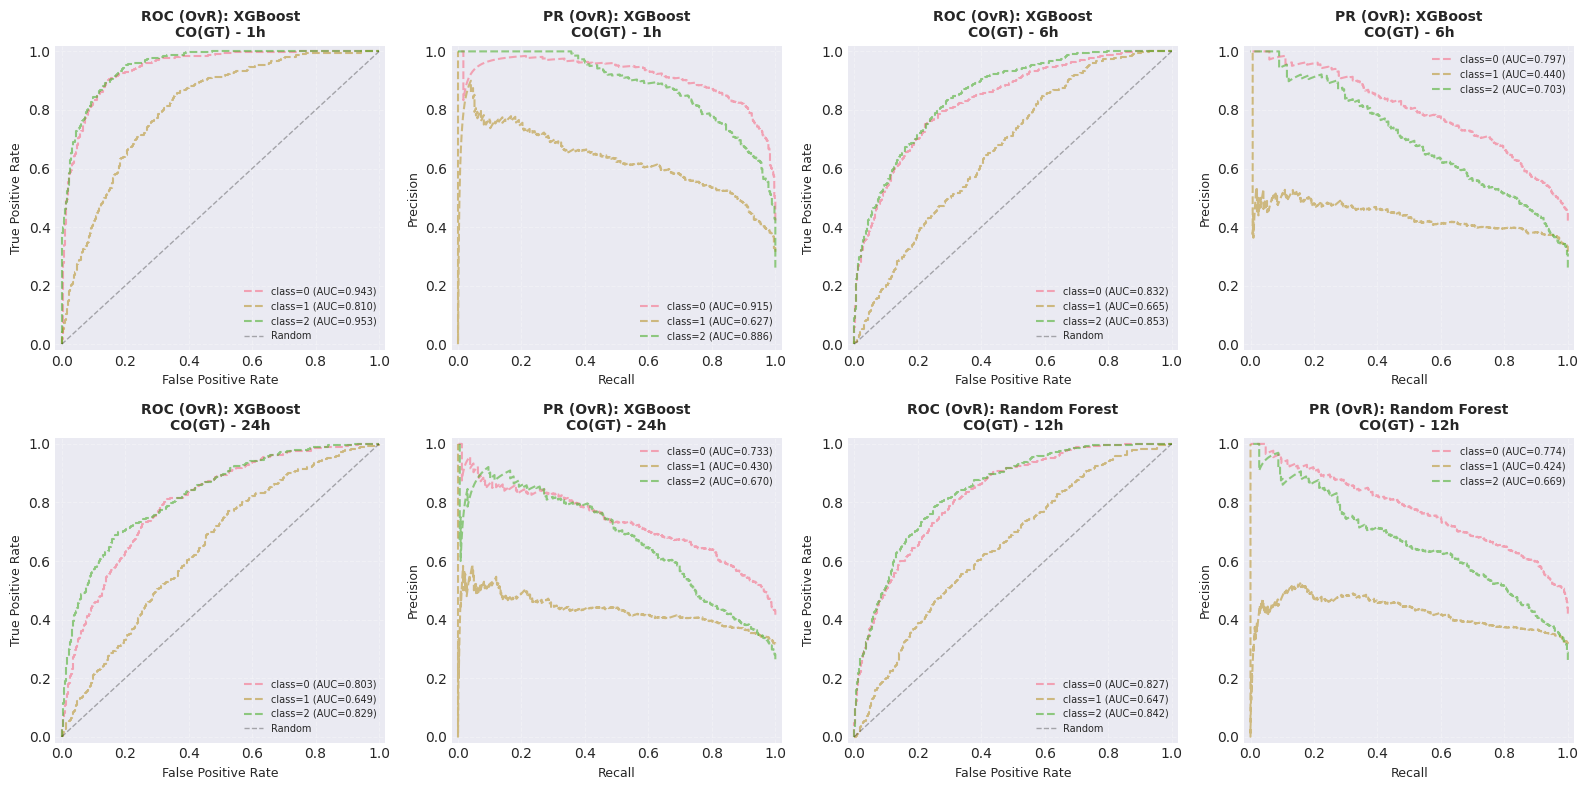

 Saved top-4 ROC/PR curves to: /root/msy/COMP9417_GoodJob-main/classification-model/outputs/figures/diagnostics/roc_pr_curves_top4.png


In [42]:
# ======================================================
# Cell 12: ROC & PR Curves - Top Models (Horizontal Layout)
# ======================================================

from sklearn.metrics import roc_curve, precision_recall_curve, auc
from sklearn.preprocessing import label_binarize

# Create diagnostics DataFrame from records collected during training
diag_df = pd.DataFrame(diagnostics_records)

if diag_df.empty:
    print(' No diagnostics records available. Please run training cells (6-10) first.')
else:
    # Add horizon_int column for easier filtering
    diag_df['horizon_int'] = diag_df['horizon'].astype(int)
    
    # Filter records that have probability outputs (needed for ROC/PR curves)
    proba_records = diag_df[diag_df['y_proba'].notna()]
    
    if proba_records.empty:
        print('No probability outputs available for ROC/PR plots.')
    else:
        # Select top 4 best models 
        selected = (
            proba_records.sort_values('F1', ascending=False, na_position='last')
                         .groupby(['pollutant', 'horizon_int'])
                         .head(1)
                         .sort_values('F1', ascending=False, na_position='last')
                         .head(4)
        )

        
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        axes = axes.flatten()

        plot_idx = 0

        for _, record in selected.iterrows():
            y_true  = np.array(record['y_true'])
            y_proba = np.array(record['y_proba'])

            
            if y_true.size == 0 or y_proba.size == 0:
                print(f" Skip empty record: {record['model']} - {record['pollutant']} - {record['horizon_int']}h")
                continue

            classes = np.unique(y_true)

            ax_roc = axes[plot_idx]
            plot_idx += 1
            ax_pr  = axes[plot_idx]
            plot_idx += 1

            # One-vs-Rest 
          
            if y_proba.ndim != 2 or y_proba.shape[1] != len(classes):
                print(f" Skip (shape mismatch, multiclass): "
                      f"{record['model']} - {record['pollutant']} - {record['horizon_int']}h, "
                      f"y_proba.shape={y_proba.shape}, classes={classes}")
                ax_roc.axis("off")
                ax_pr.axis("off")
                continue

            
            Y_bin = label_binarize(y_true, classes=classes)

           
            for cls_idx, cls in enumerate(classes):
                y_true_c = Y_bin[:, cls_idx]
                y_score_c = y_proba[:, cls_idx]

                if np.unique(y_true_c).size < 2:
                    continue

                # ROC
                fpr_c, tpr_c, _ = roc_curve(y_true_c, y_score_c)
                roc_auc_c = auc(fpr_c, tpr_c)
                ax_roc.plot(
                    fpr_c, tpr_c,
                    lw=1.5,
                    alpha=0.6,
                    linestyle='--',
                    label=f'class={cls} (AUC={roc_auc_c:.3f})'
                )

                # PR
                precision_c, recall_c, _ = precision_recall_curve(y_true_c, y_score_c)
                pr_auc_c = auc(recall_c, precision_c)
                ax_pr.plot(
                    recall_c, precision_c,
                    lw=1.5,
                    alpha=0.6,
                    linestyle='--',
                    label=f'class={cls} (AUC={pr_auc_c:.3f})'
                )

            ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.0, alpha=0.3, label='Random')
            ax_roc.set_title(
                f"ROC (OvR): {record['model']}\n{record['pollutant']} - {record['horizon_int']}h",
                fontsize=10, fontweight='bold'
            )
            ax_roc.set_xlabel("False Positive Rate", fontsize=9)
            ax_roc.set_ylabel("True Positive Rate", fontsize=9)
            ax_roc.legend(fontsize=7, loc='lower right')
            ax_roc.grid(alpha=0.3, linestyle='--')
            ax_roc.set_xlim([-0.02, 1.02])
            ax_roc.set_ylim([-0.02, 1.02])

            ax_pr.set_title(
                f"PR (OvR): {record['model']}\n{record['pollutant']} - {record['horizon_int']}h",
                fontsize=10, fontweight='bold'
            )
            ax_pr.set_xlabel("Recall", fontsize=9)
            ax_pr.set_ylabel("Precision", fontsize=9)
            ax_pr.legend(fontsize=7, loc='best')
            ax_pr.grid(alpha=0.3, linestyle='--')
            ax_pr.set_xlim([-0.02, 1.02])
            ax_pr.set_ylim([-0.02, 1.02])

        # Hide unused subplots
        while plot_idx < len(axes):
            axes[plot_idx].axis("off")
            plot_idx += 1

        plt.tight_layout()
        save_path = DIAGNOSTICS_DIR / "roc_pr_curves_top4.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

        print(f" Saved top-4 ROC/PR curves to: {save_path}")


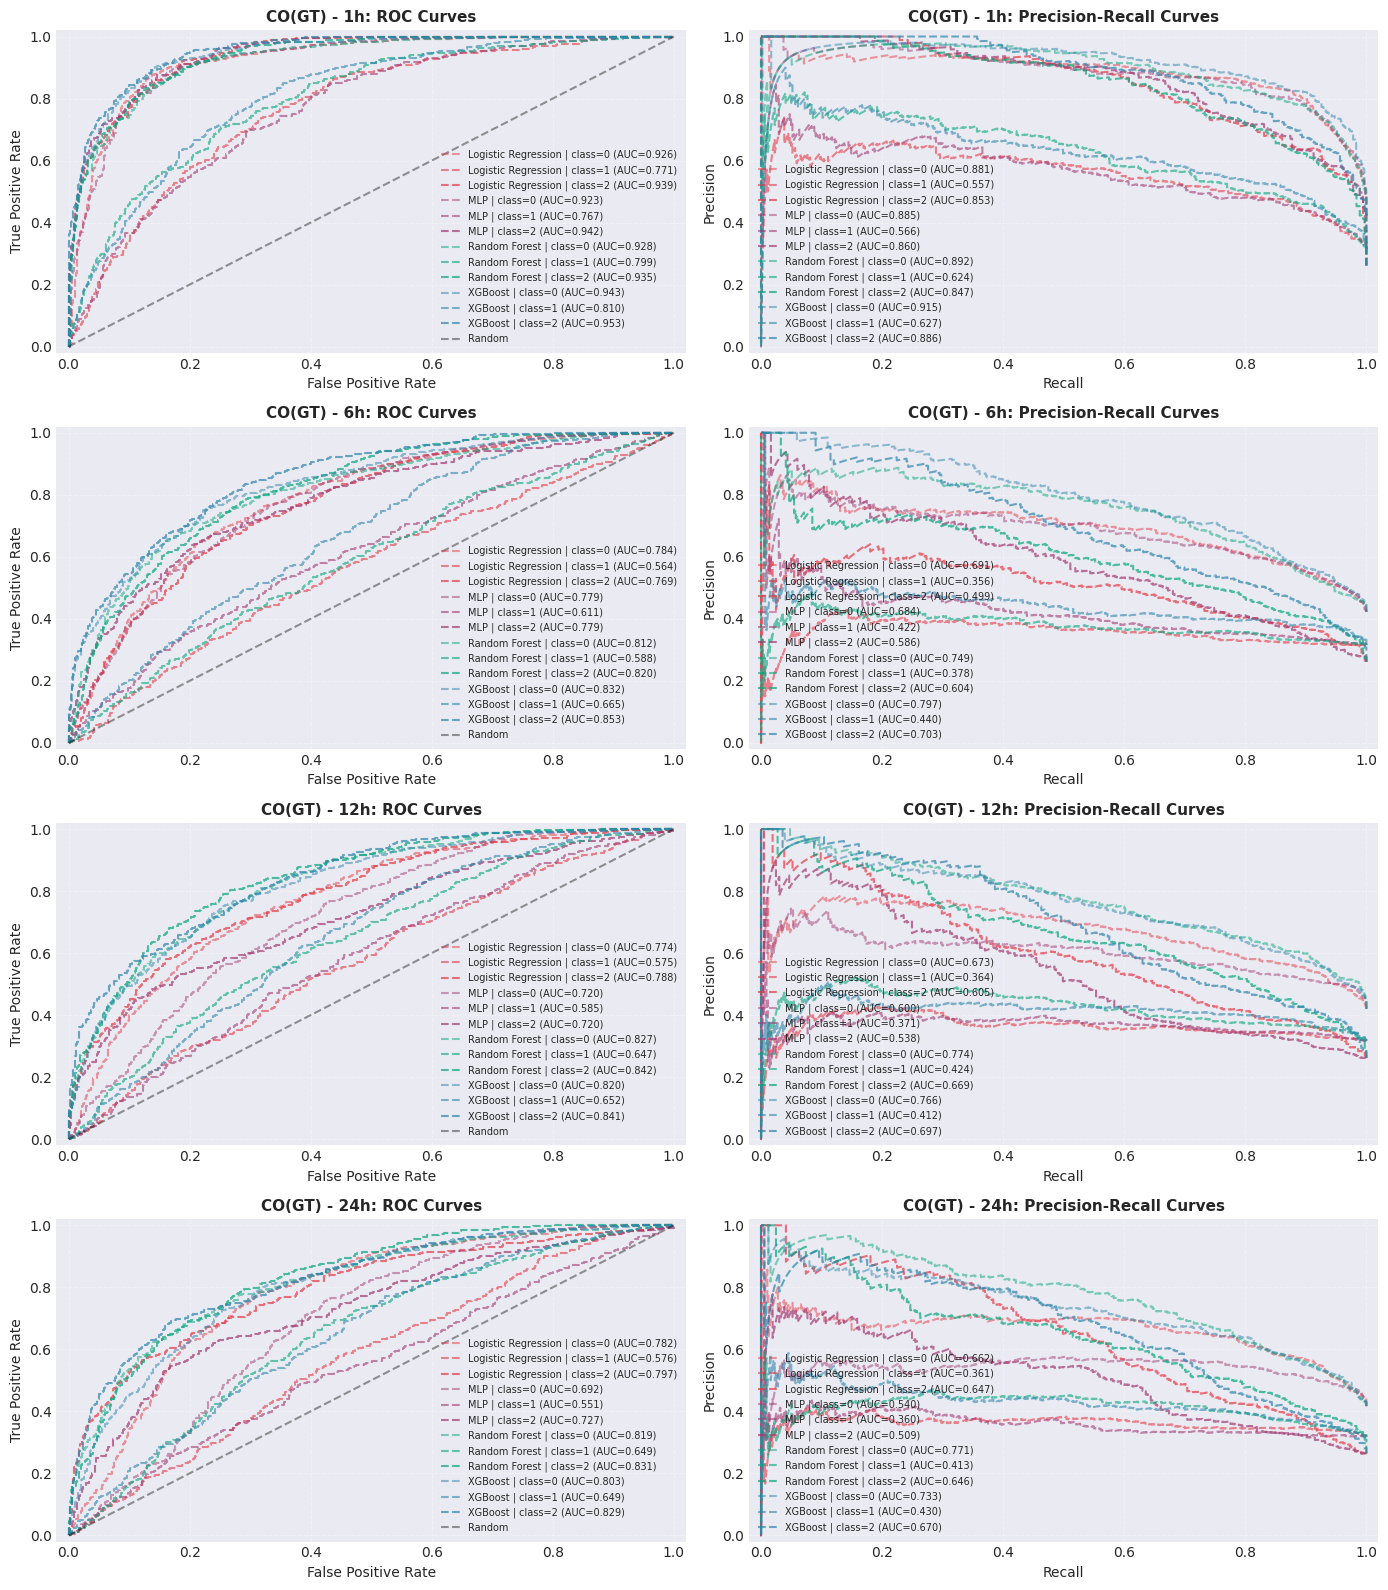

 Saved model comparison for CO(GT): /root/msy/COMP9417_GoodJob-main/classification-model/outputs/figures/performance/CO_model_comparison.png


In [43]:
# ======================================================
# Cell 13: Model Performance Comparison - ROC/PR Line Charts (Multi-class OvR)
# ======================================================

from sklearn.metrics import roc_curve, precision_recall_curve, auc
from sklearn.preprocessing import label_binarize

# Use diag_df created in Cell 12
if diag_df.empty:
    print(' No diagnostics available. ')
else:
    # Iterate through each pollutant
    for pollutant in diag_df['pollutant'].unique():
        
        # Create subplot grid: 4 rows (one per horizon) × 2 columns (ROC & PR)
        fig, axes = plt.subplots(len(HORIZONS), 2, figsize=(14, 4 * len(HORIZONS)))
        
        # Define colors for different models
        colors = {
            'Logistic Regression': '#E63946',
            'Ridge Classifier': '#F77F00',
            'Random Forest': '#06A77D',
            'XGBoost': '#2E86AB',
            'MLP': '#A23B72',
            'Persistence Baseline': '#6C757D'
        }
        
        for row_idx, horizon in enumerate(HORIZONS):
            # Get all models for this pollutant and horizon
            subset = diag_df[(diag_df['pollutant'] == pollutant) & 
                             (diag_df['horizon_int'] == horizon)]

            ax_roc = axes[row_idx, 0]
            ax_pr  = axes[row_idx, 1]

            if subset.empty:
                ax_roc.set_title(f'{horizon}h - No data available', fontsize=11)
                ax_pr.set_title(f'{horizon}h - No data available', fontsize=11)
                ax_roc.axis('off')
                ax_pr.axis('off')
                continue

            model_plotted = False

            for model_name in sorted(subset['model'].unique()):
                model_records = subset[subset['model'] == model_name]
                
                # Get best record for this model
                record = model_records.sort_values('F1', ascending=False, na_position='last').iloc[0]

                # Skip if no probability output
                if record['y_proba'] is None:
                    continue

                y_true  = np.array(record['y_true'])
                y_proba = np.array(record['y_proba'])

                if y_true.size == 0:
                    continue

                classes = np.unique(y_true)
                color = colors.get(model_name, '#000000')

                # =========================
                # One-vs-Rest
                # =========================
               
                if y_proba.ndim != 2 or y_proba.shape[1] != len(classes):
                    print(f" Skipping {pollutant}-{horizon}h {model_name}: "
                          f"multi-class but y_proba shape {y_proba.shape} "
                          f"!= n_classes={len(classes)}")
                    continue

            
                Y_bin = label_binarize(y_true, classes=classes)  

           
                for cls_idx, cls in enumerate(classes):
                    y_true_c = Y_bin[:, cls_idx]
                    y_score_c = y_proba[:, cls_idx]

                   
                    if np.unique(y_true_c).size < 2:
                        continue

                    # ROC
                    fpr_c, tpr_c, _ = roc_curve(y_true_c, y_score_c)
                    roc_auc_c = auc(fpr_c, tpr_c)

                    #  PR
                    precision_c, recall_c, _ = precision_recall_curve(y_true_c, y_score_c)
                    pr_auc_c = auc(recall_c, precision_c)

                    ax_roc.plot(
                        fpr_c, tpr_c,
                        lw=1.5,
                        color=color,
                        alpha=0.5 + 0.1 * min(cls_idx, 3),  
                        linestyle='--',
                        label=f'{model_name} | class={cls} (AUC={roc_auc_c:.3f})'
                    )

                    ax_pr.plot(
                        recall_c, precision_c,
                        lw=1.5,
                        color=color,
                        alpha=0.5 + 0.1 * min(cls_idx, 3),
                        linestyle='--',
                        label=f'{model_name} | class={cls} (AUC={pr_auc_c:.3f})'
                    )

                    model_plotted = True

            # subplot 
            if model_plotted:
                
                ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4, lw=1.5, label='Random')
            ax_roc.set_title(
                f'{pollutant} - {horizon}h: ROC Curves',
                fontsize=11, fontweight='bold'
            )
            ax_roc.set_xlabel('False Positive Rate', fontsize=10)
            ax_roc.set_ylabel('True Positive Rate', fontsize=10)
            ax_roc.legend(fontsize=7, loc='lower right', ncol=1)
            ax_roc.grid(alpha=0.3, linestyle='--')
            ax_roc.set_xlim([-0.02, 1.02])
            ax_roc.set_ylim([-0.02, 1.02])

            ax_pr.set_title(
                f'{pollutant} - {horizon}h: Precision-Recall Curves',
                fontsize=11, fontweight='bold'
            )
            ax_pr.set_xlabel('Recall', fontsize=10)
            ax_pr.set_ylabel('Precision', fontsize=10)
            ax_pr.legend(fontsize=7, loc='best', ncol=1)
            ax_pr.grid(alpha=0.3, linestyle='--')
            ax_pr.set_xlim([-0.02, 1.02])
            ax_pr.set_ylim([-0.02, 1.02])

        plt.tight_layout()
        out_path = PERFORMANCE_DIR / f"{pollutant.replace('(GT)', '')}_model_comparison.png"
        plt.savefig(out_path, dpi=300, bbox_inches='tight')
        plt.show()

        print(f" Saved model comparison for {pollutant}: {out_path}")


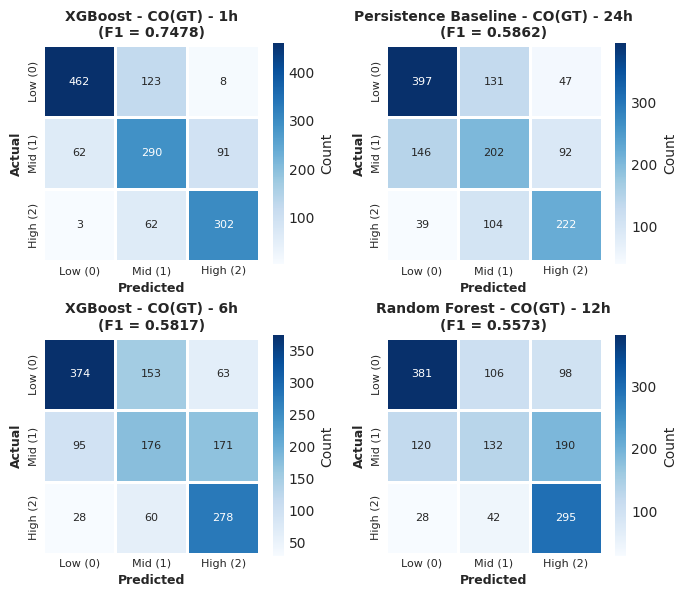

 Saved confusion matrices to: /root/msy/COMP9417_GoodJob-main/classification-model/outputs/figures/diagnostics/confusion_matrices_top4.png
  Top 4 models displayed


In [44]:
# ======================================================
# Cell 14: Confusion Matrices - Top Models (Smaller, 2×2 Layout)
# ======================================================

from sklearn.metrics import confusion_matrix


if diag_df.empty:
    print(' No diagnostics records available. ')
else:
    
    if 'horizon_int' not in diag_df.columns:
        diag_df['horizon_int'] = diag_df['horizon'].astype(int)

    # select  pollutant × horizon_int  F1 highest 
    top_combos = (
        diag_df.sort_values('F1', ascending=False, na_position='last')
        .groupby(['pollutant', 'horizon_int'])
        .head(1)
        .sort_values('F1', ascending=False, na_position='last')
        .head(4)
    )

    if len(top_combos) == 0:
        print(' No models to display.')
    else:
        n_models = len(top_combos)

        
        n_cols = 2
        n_rows = int(np.ceil(n_models / n_cols))
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(7, 3 * n_rows))

        
        axes = np.array(axes).reshape(-1)
        

        for ax, (_, record) in zip(axes, top_combos.iterrows()):
            pol         = record['pollutant']
            horizon_int = record['horizon_int']
            model_name  = record['model']
            f1_score    = record['F1']

            
            y_true = np.array(record['y_true'])
            y_pred = np.array(record['y_pred'])

            
            if y_true.size == 0 or y_pred.size == 0:
                ax.axis("off")
                print(f" Skip empty record in confusion matrix: {model_name} - {pol} - {horizon_int}h")
                continue

            
            labels = np.unique(np.concatenate([y_true, y_pred]))
            cm = confusion_matrix(y_true, y_pred, labels=labels)
            n_classes = len(labels)

            
            if n_classes == 3 and set(labels) == {0, 1, 2}:
                class_labels = ['Low (0)', 'Mid (1)', 'High (2)']
            else:
                class_labels = [str(l) for l in labels]

    
            sns.heatmap(
                cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                cbar=True,
                ax=ax,
                square=True,
                linewidths=1,
                linecolor='white',
                xticklabels=class_labels,
                yticklabels=class_labels,
                cbar_kws={'label': 'Count'},
                annot_kws={'size': 8}   
            )

            ax.set_title(
                f"{model_name} - {pol} - {horizon_int}h\n(F1 = {f1_score:.4f})",
                fontsize=10,
                fontweight='bold',
                pad=6
            )
            ax.set_xlabel("Predicted", fontsize=9, fontweight='bold')
            ax.set_ylabel("Actual",   fontsize=9, fontweight='bold')
            ax.tick_params(axis='both', labelsize=8)

       
        for j in range(n_models, len(axes)):
            axes[j].axis("off")

        plt.tight_layout()
        save_path = DIAGNOSTICS_DIR / 'confusion_matrices_top4.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

        print(f' Saved confusion matrices to: {save_path}')
        print(f'  Top {n_models} models displayed')


Feature Importance Analysis for Random Forest & XGBoost)
 feature importance figure: CO(GT) - 1h (XGBoost)
 feature importance figure: CO(GT) - 6h (XGBoost)
 feature importance figure: CO(GT) - 12h (Random Forest)


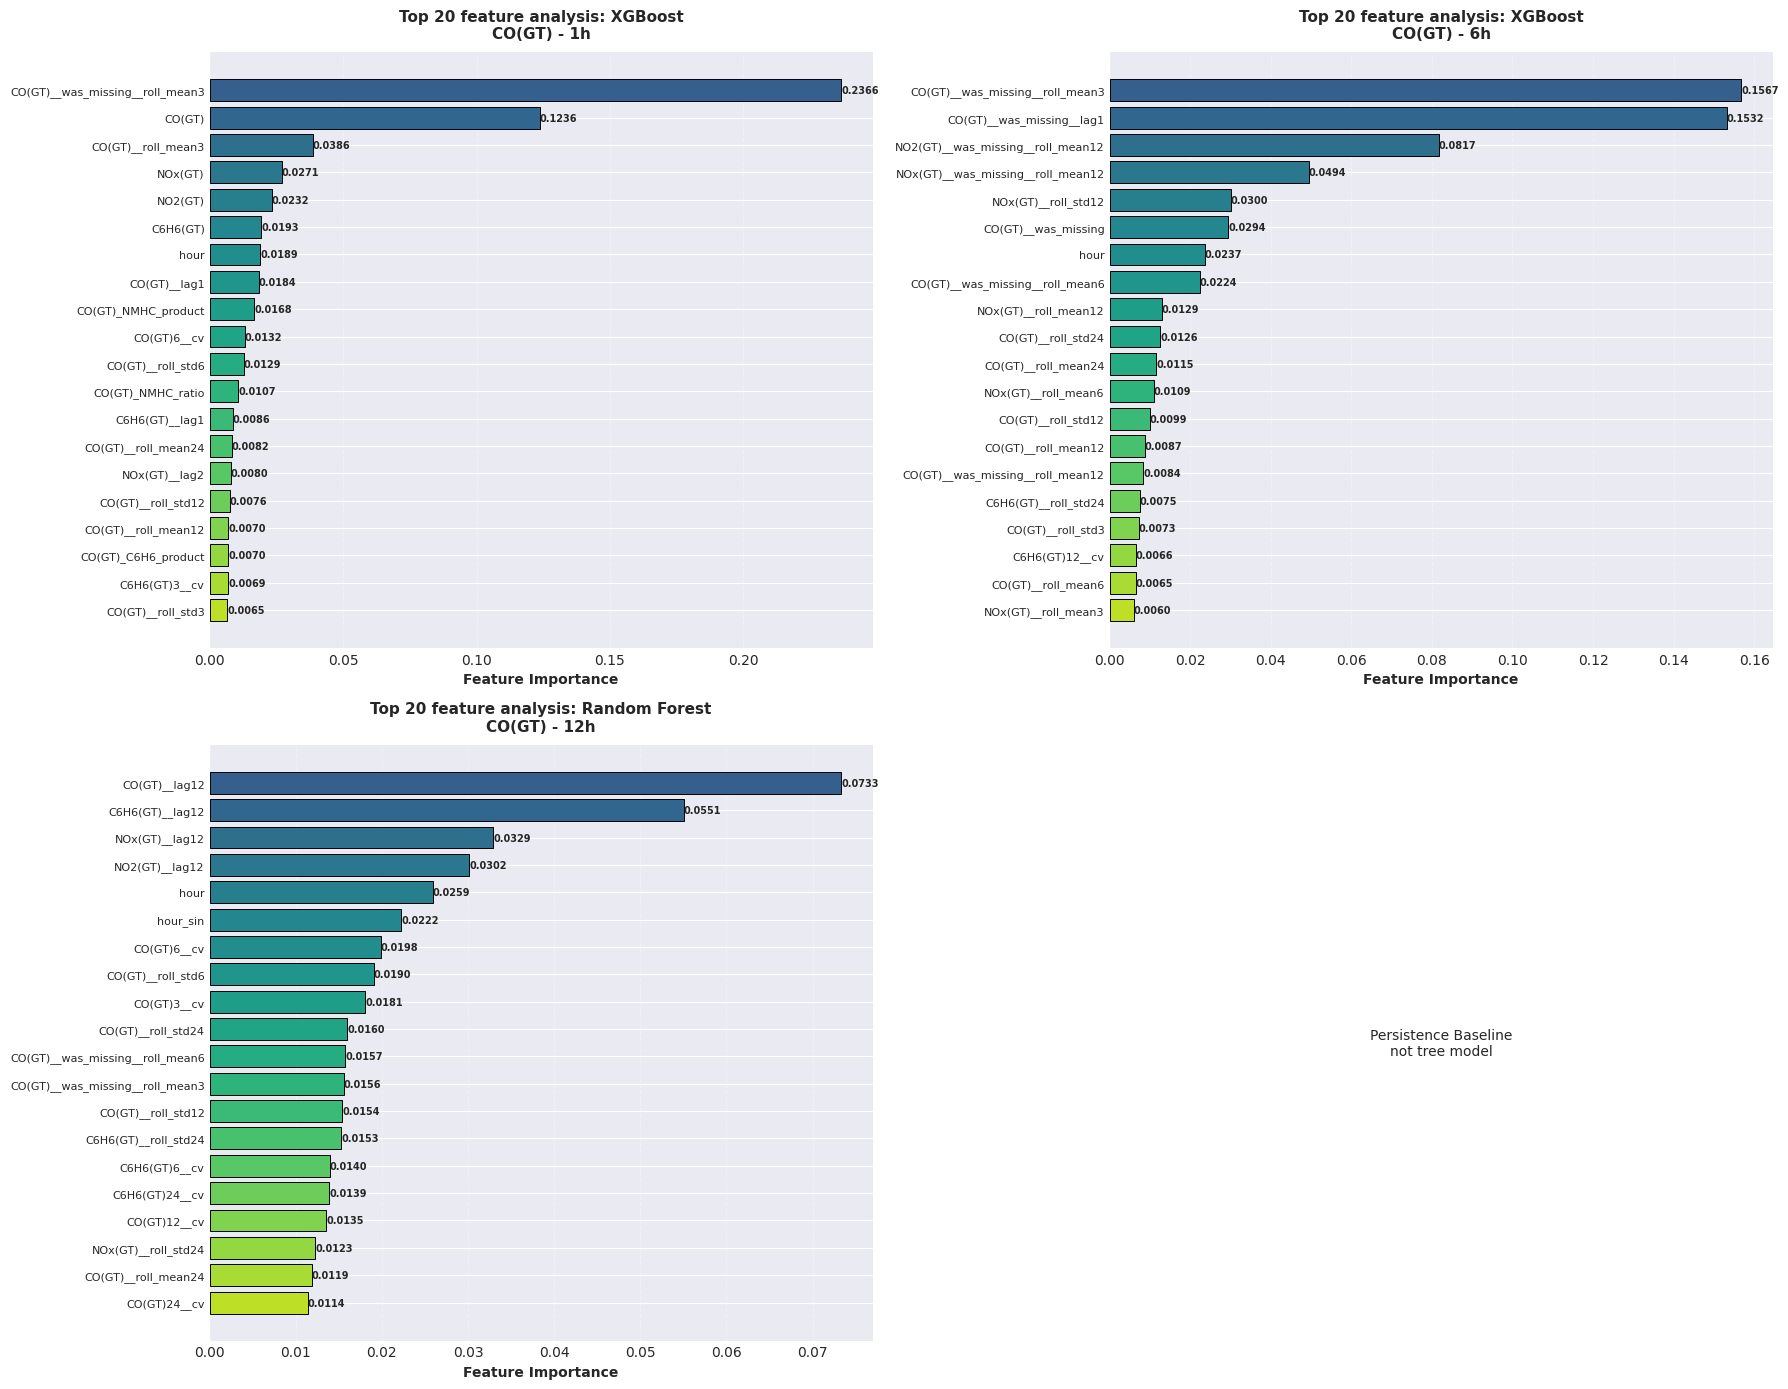

 save feature importance figure : /root/msy/COMP9417_GoodJob-main/classification-model/outputs/figures/diagnostics/feature_importance_CO.png



In [45]:
# ======================================================
# Cell: Feature Importance Analysis 

# ======================================================

print("=" * 80)
print("Feature Importance Analysis for Random Forest & XGBoost)")
print("=" * 80)

#  (Random Forest & XGBoost)
tree_based_models = [m for m in trained_tree_models if m['model'] in ['Random Forest', 'XGBoost']]

if len(tree_based_models) == 0:
    print("no tree models found. Please run training cells (Cells 8-10) first.")
else:
    
    for pollutant in CLASS_TARGETS:
        
        pollutant_models = [m for m in tree_based_models if m['pollutant'] == pollutant]
        
        if len(pollutant_models) == 0:
            continue
      
        fig, axes = plt.subplots(2, 2, figsize=(18, 14))
        axes = axes.flatten()
        
        for idx, horizon in enumerate(HORIZONS):
            ax = axes[idx]
            
        
            horizon_models = [m for m in pollutant_models if m['horizon'] == horizon]
            
            if len(horizon_models) == 0:
                ax.axis('off')
                ax.set_title(f'{pollutant} - {horizon}h\n no available model', fontsize=11)
                continue
            
          
            importance_dict = {}
            
            for model_info in horizon_models:
                model_name = model_info['model']
                estimator = model_info['estimator']
                feature_names = model_info['feature_names']
                
             
                if model_name == 'Random Forest':
                    # Random Forest use feature_importances_
                    importances = estimator.named_steps['model'].feature_importances_
                elif model_name == 'XGBoost':
                    # XGBoost use feature_importances_
                    importances = estimator.feature_importances_
                else:
                    continue
                
                
                importance_dict[model_name] = {
                    'features': feature_names,
                    'importance': importances
                }
            
            if len(importance_dict) == 0:
                ax.axis('off')
                continue
            
            
            best_record = best_models[
                (best_models['pollutant'] == pollutant) & 
                (best_models['horizon_int'] == horizon)
            ]
            
            if not best_record.empty:
                best_model_name = best_record.iloc[0]['model']
                
                if best_model_name in importance_dict:
                    feat_names = importance_dict[best_model_name]['features']
                    feat_importance = importance_dict[best_model_name]['importance']
                    
          
                    importance_df = pd.DataFrame({
                        'Feature': feat_names,
                        'Importance': feat_importance
                    }).sort_values('Importance', ascending=False).head(20)  # Top 20
                    
                
                    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance_df)))
                    bars = ax.barh(range(len(importance_df)), 
                                   importance_df['Importance'], 
                                   color=colors,
                                   edgecolor='black', 
                                   linewidth=0.7)
                    
                  
                    ax.set_yticks(range(len(importance_df)))
                    ax.set_yticklabels(importance_df['Feature'], fontsize=8)
                    ax.invert_yaxis()  
                    
                   
                    for i, (bar, val) in enumerate(zip(bars, importance_df['Importance'])):
                        ax.text(val, i, f'{val:.4f}', 
                               va='center', ha='left', 
                               fontsize=7, fontweight='bold')
                    
                    
                    ax.set_title(
                        f'Top 20 feature analysis: {best_model_name}\n{pollutant} - {horizon}h',
                        fontsize=11, fontweight='bold', pad=10
                    )
                    ax.set_xlabel('Feature Importance', fontsize=10, fontweight='bold')
                    ax.grid(axis='x', alpha=0.3, linestyle='--')
                    
                    print(f" feature importance figure: {pollutant} - {horizon}h ({best_model_name})")
                else:
                    ax.axis('off')
                    ax.text(0.5, 0.5, f'{best_model_name}\nnot tree model', 
                           transform=ax.transAxes, ha='center', va='center')
            else:
                ax.axis('off')
        
        plt.tight_layout()
        save_path = DIAGNOSTICS_DIR / f'feature_importance_{pollutant.replace("(GT)", "")}.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f" save feature importance figure : {save_path}\n")




  Class Distribution Statistics
--------------------------------------------------------------------------------
Pollutant Horizon  Total  Class 0 (Low)  Class 1 (Mid)  Class 2 (High)  Imbalance Ratio  Gini Impurity  Entropy
   CO(GT)      1h   6525           1900           2958            1667         1.774445       0.644429 1.538690
   CO(GT)      6h   6525           1900           2959            1666         1.776110       0.644368 1.538563
   CO(GT)     12h   6525           1899           2959            1667         1.775045       0.644379 1.538592
   CO(GT)     24h   6525           1904           2961            1660         1.783735       0.644202 1.538189


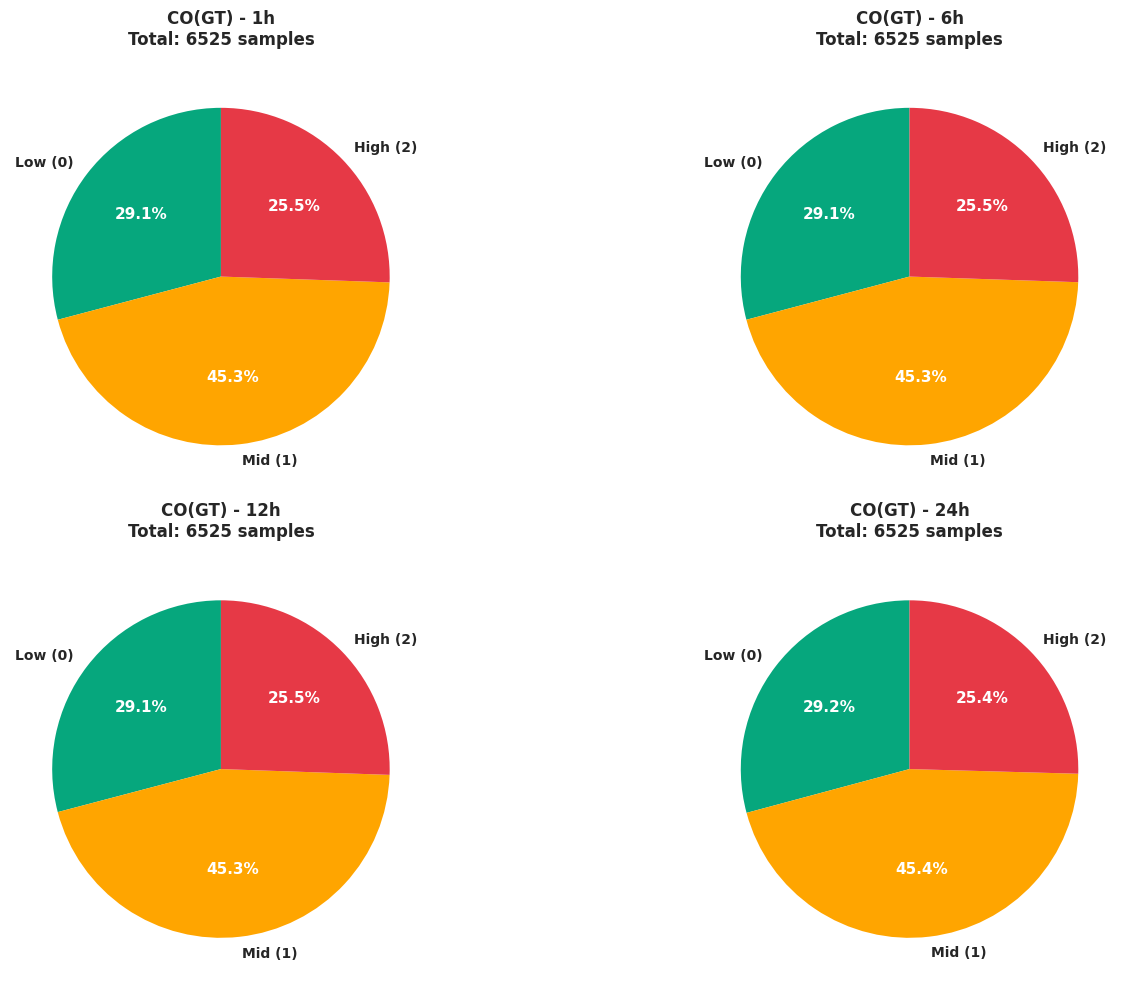

 Saved class distribution figure: /root/msy/COMP9417_GoodJob-main/classification-model/outputs/figures/diagnostics/class_distribution_analysis.png

CO(GT):

1h - XGBoost
------------------------------------------------------------
              precision    recall  f1-score   support

     Low (0)     0.8767    0.7791    0.8250       593
     Mid (1)     0.6105    0.6546    0.6318       443
    High (2)     0.7531    0.8229    0.7865       367

    accuracy                         0.7512      1403
   macro avg     0.7468    0.7522    0.7478      1403
weighted avg     0.7603    0.7512    0.7539      1403

 Performance Analysis:
   • Best-performing class: Class 0 (Low (0)) - F1=0.8250
   • Worst-performing class: Class 1 (Mid (1)) - F1=0.6318
   • F1 gap: 0.1932

6h - XGBoost
------------------------------------------------------------
              precision    recall  f1-score   support

     Low (0)     0.7525    0.6339    0.6881       590
     Mid (1)     0.4524    0.3982    0.4236 

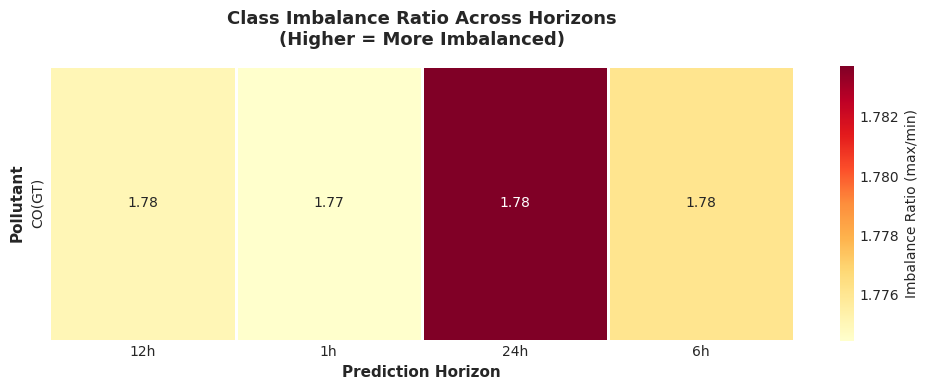

 Saved imbalance ratio heatmap: /root/msy/COMP9417_GoodJob-main/classification-model/outputs/figures/diagnostics/imbalance_ratio_heatmap.png

Class imbalance analysis completed


In [46]:
# ======================================================
# Cell: Class Imbalance Deep Analysis
# ======================================================

from sklearn.metrics import classification_report
from scipy.stats import chi2_contingency

print("\n  Class Distribution Statistics")
print("-" * 80)

imbalance_stats = []

for pollutant in CLASS_TARGETS:
    for h in HORIZONS:
        if h not in CLASS_TARGETS[pollutant]:
            continue
        
        info = CLASS_TARGETS[pollutant][h]
        class_dist = info['class_distribution']
        
        total = sum(class_dist.values())
        if total == 0:
            continue
        
        # Imbalance Ratio
        max_class_count = max(class_dist.values())
        min_class_count = min(class_dist.values())
        imbalance_ratio = max_class_count / min_class_count if min_class_count > 0 else np.inf
        
        # Gini Impurity
        gini = 1 - sum((count/total)**2 for count in class_dist.values())
        
        # Entropy
        entropy = -sum((count/total) * np.log2(count/total) if count > 0 else 0 
                      for count in class_dist.values())
        
        imbalance_stats.append({
            'Pollutant': pollutant,
            'Horizon': f'{h}h',
            'Total': total,
            'Class 0 (Low)': class_dist.get(0, 0),
            'Class 1 (Mid)': class_dist.get(1, 0),
            'Class 2 (High)': class_dist.get(2, 0),
            'Imbalance Ratio': imbalance_ratio,
            'Gini Impurity': gini,
            'Entropy': entropy
        })

imbalance_df = pd.DataFrame(imbalance_stats)
print(imbalance_df.to_string(index=False))


# ---------------------------
# Pie Charts for Class Distribution
# ---------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, h in enumerate(HORIZONS):
    ax = axes[idx]
    
    for pollutant in CLASS_TARGETS:
        if h not in CLASS_TARGETS[pollutant]:
            continue
        
        info = CLASS_TARGETS[pollutant][h]
        class_dist = info['class_distribution']
        
        labels = ['Low (0)', 'Mid (1)', 'High (2)']
        counts = [class_dist.get(i, 0) for i in range(3)]
        colors = ['#06A77D', '#FFA500', '#E63946']
        
        
        wedges, texts, autotexts = ax.pie(
            counts, 
            labels=labels, 
            colors=colors,
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 10, 'fontweight': 'bold'}
        )
        
        # Enhance autopct text
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontsize(11)
        
        ax.set_title(f'{pollutant} - {h}h\nTotal: {sum(counts)} samples', 
                    fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
save_path = DIAGNOSTICS_DIR / 'class_distribution_analysis.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f" Saved class distribution figure: {save_path}")


# ---------------------------
# Classification Report for Best Models
# ---------------------------

for pollutant in CLASS_TARGETS:
    print(f"\n{pollutant}:")
    print("=" * 60)
    
    for h in HORIZONS:
    
        best_record = best_models[
            (best_models['pollutant'] == pollutant) & 
            (best_models['horizon_int'] == h)
        ]
        
        if best_record.empty:
            continue
        
        best_model_name = best_record.iloc[0]['model']
        
        matching_diag = [
            d for d in diagnostics_records 
            if d['model'] == best_model_name and 
               d['pollutant'] == pollutant and 
               d['horizon'] == h
        ]
        
        if not matching_diag:
            continue
        
        y_true = np.array(matching_diag[0]['y_true'])
        y_pred = np.array(matching_diag[0]['y_pred'])
        
        print(f"\n{h}h - {best_model_name}")
        print("-" * 60)
        
      
        target_names = ['Low (0)', 'Mid (1)', 'High (2)']
        report = classification_report(
            y_true, y_pred, 
            target_names=target_names,
            digits=4,
            zero_division=0
        )
        print(report)
        
        
        from sklearn.metrics import precision_recall_fscore_support
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, average=None, zero_division=0
        )
        
        worst_class = np.argmin(f1)
        best_class = np.argmax(f1)
        
        print(f" Performance Analysis:")
        print(f"   • Best-performing class: Class {best_class} ({target_names[best_class]}) - F1={f1[best_class]:.4f}")
        print(f"   • Worst-performing class: Class {worst_class} ({target_names[worst_class]}) - F1={f1[worst_class]:.4f}")
        print(f"   • F1 gap: {f1[best_class] - f1[worst_class]:.4f}")


# ---------------------------
# 4. Imbalance Ratio Heatmap
# ---------------------------

print("\n Imbalance Ratio Heatmap")
print("-" * 80)

pivot_data = imbalance_df.pivot_table(
    values='Imbalance Ratio', 
    index='Pollutant', 
    columns='Horizon'
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    pivot_data, 
    annot=True, 
    fmt='.2f', 
    cmap='YlOrRd', 
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Imbalance Ratio (max/min)'},
    ax=ax
)
ax.set_title('Class Imbalance Ratio Across Horizons\n(Higher = More Imbalanced)', 
            fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Prediction Horizon', fontsize=11, fontweight='bold')
ax.set_ylabel('Pollutant', fontsize=11, fontweight='bold')

plt.tight_layout()
save_path = DIAGNOSTICS_DIR / 'imbalance_ratio_heatmap.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f" Saved imbalance ratio heatmap: {save_path}")

print("\n" + "=" * 80)
print("Class imbalance analysis completed")
print("=" * 80)


Error Analysis
Analyze which samples were misclassified and the patterns of errors

 Error Type Statistics
--------------------------------------------------------------------------------
Pollutant Horizon                Model  Total Samples  Total Errors  Error Rate (%)  Over-predictions  Under-predictions  Severe Errors (±2)  Severe Error Rate (%)
   CO(GT)      1h              XGBoost           1403           349       24.875267               222                127                  11               0.784034
   CO(GT)      6h              XGBoost           1398           570       40.772532               387                183                  91               6.509299
   CO(GT)     12h        Random Forest           1392           584       41.954023               394                190                 126               9.051724
   CO(GT)     24h Persistence Baseline           1380           559       40.507246               270                289                  86               6

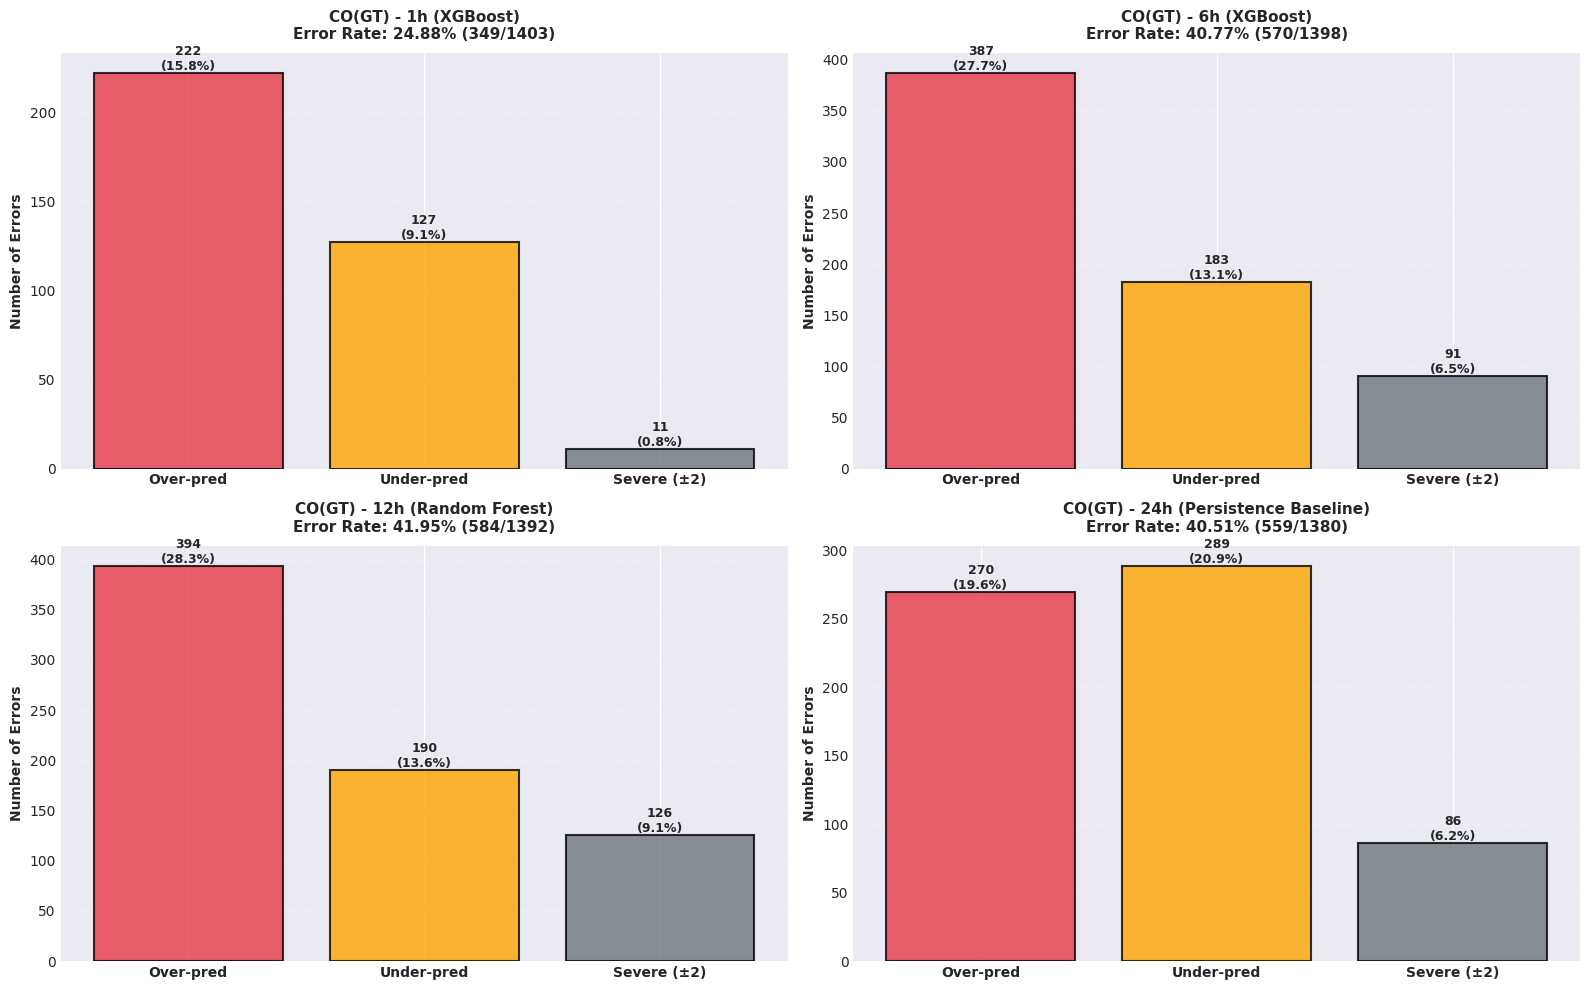

 Saved error type analysis figure: /root/msy/COMP9417_GoodJob-main/classification-model/outputs/figures/diagnostics/error_type_analysis.png

 Error Sample Feature Analysis
--------------------------------------------------------------------------------

CO(GT):

1h - XGBoost - Error Transition Matrix:
------------------------------------------------------------
            Pred: Low  Pred: Mid  Pred: High
True: Low         462        123           8
True: Mid          62        290          91
True: High          3         62         302

Error Rate per Class:
  Class 0 (Low): 131/593 = 22.09% error rate
  Class 1 (Mid): 153/443 = 34.54% error rate
  Class 2 (High): 65/367 = 17.71% error rate

6h - XGBoost - Error Transition Matrix:
------------------------------------------------------------
            Pred: Low  Pred: Mid  Pred: High
True: Low         374        153          63
True: Mid          95        176         171
True: High         28         60         278

Error Rate per 

In [47]:
# ======================================================
# Cell: Error Analysis
# ======================================================

print("=" * 80)
print("Error Analysis")
print("Analyze which samples were misclassified and the patterns of errors")
print("=" * 80)

# 1. Count error types and error rates for each model
print("\n Error Type Statistics")
print("-" * 80)

error_analysis_data = []

for pollutant in CLASS_TARGETS:
    for h in HORIZONS:
        # Get best model for this pollutant & horizon
        best_record = best_models[
            (best_models['pollutant'] == pollutant) & 
            (best_models['horizon_int'] == h)
        ]
        
        if best_record.empty:
            continue
        
        best_model_name = best_record.iloc[0]['model']
        
        # Retrieve predictions from diagnostics_records
        matching_diag = [
            d for d in diagnostics_records 
            if d['model'] == best_model_name and 
               d['pollutant'] == pollutant and 
               d['horizon'] == h
        ]
        
        if not matching_diag:
            continue
        
        y_true = np.array(matching_diag[0]['y_true'])
        y_pred = np.array(matching_diag[0]['y_pred'])
        
        # Compute errors
        errors = y_true != y_pred
        n_errors = np.sum(errors)
        error_rate = n_errors / len(y_true) if len(y_true) > 0 else 0
        
        # Error type analysis
        # Over-prediction: predicted class > true class
        over_pred = np.sum((y_pred > y_true) & errors)
        # Under-prediction: predicted class < true class
        under_pred = np.sum((y_pred < y_true) & errors)
        
        # Severe error: class difference = 2 (0→2 or 2→0)
        severe_errors = np.sum(np.abs(y_pred - y_true) == 2)
        
        error_analysis_data.append({
            'Pollutant': pollutant,
            'Horizon': f'{h}h',
            'Model': best_model_name,
            'Total Samples': len(y_true),
            'Total Errors': n_errors,
            'Error Rate (%)': error_rate * 100,
            'Over-predictions': over_pred,
            'Under-predictions': under_pred,
            'Severe Errors (±2)': severe_errors,
            'Severe Error Rate (%)': (severe_errors / len(y_true) * 100) if len(y_true) > 0 else 0
        })

error_df = pd.DataFrame(error_analysis_data)
print(error_df.to_string(index=False))

# 2. Visualize error type distribution
print("\n Error Type Visualization")
print("-" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, h in enumerate(HORIZONS):
    ax = axes[idx]
    
    horizon_data = error_df[error_df['Horizon'] == f'{h}h']
    
    if horizon_data.empty:
        ax.axis('off')
        continue
    
    # Bar chart categories
    categories = ['Over-pred', 'Under-pred', 'Severe (±2)']
    
    for _, row in horizon_data.iterrows():
        values = [
            row['Over-predictions'],
            row['Under-predictions'],
            row['Severe Errors (±2)']
        ]
        
        x = np.arange(len(categories))
        colors = ['#E63946', '#FFA500', '#6C757D']
        
        bars = ax.bar(x, values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
        
        # Add value text labels
        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2., 
                height,
                f'{int(val)}\n({val / row["Total Samples"] * 100:.1f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold'
            )
        
        ax.set_title(
            f'{row["Pollutant"]} - {h}h ({row["Model"]})\n'
            f'Error Rate: {row["Error Rate (%)"]:.2f}% ({row["Total Errors"]}/{row["Total Samples"]})',
            fontsize=11, fontweight='bold', pad=10
        )
        ax.set_xticks(x)
        ax.set_xticklabels(categories, fontsize=10, fontweight='bold')
        ax.set_ylabel('Number of Errors', fontsize=10, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
save_path = DIAGNOSTICS_DIR / 'error_type_analysis.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f" Saved error type analysis figure: {save_path}")

# 3. Error sample pattern analysis
print("\n Error Sample Feature Analysis")
print("-" * 80)

for pollutant in CLASS_TARGETS:
    print(f"\n{pollutant}:")
    print("=" * 60)
    
    for h in HORIZONS:
        best_record = best_models[
            (best_models['pollutant'] == pollutant) & 
            (best_models['horizon_int'] == h)
        ]
        
        if best_record.empty:
            continue
        
        best_model_name = best_record.iloc[0]['model']
        
        matching_diag = [
            d for d in diagnostics_records 
            if d['model'] == best_model_name and 
               d['pollutant'] == pollutant and 
               d['horizon'] == h
        ]
        
        if not matching_diag:
            continue
        
        y_true = np.array(matching_diag[0]['y_true'])
        y_pred = np.array(matching_diag[0]['y_pred'])
        
        print(f"\n{h}h - {best_model_name} - Error Transition Matrix:")
        print("-" * 60)
        
        transition_matrix = np.zeros((3, 3), dtype=int)
        for true_class, pred_class in zip(y_true, y_pred):
            transition_matrix[true_class, pred_class] += 1
        
        transition_df = pd.DataFrame(
            transition_matrix,
            index=['True: Low', 'True: Mid', 'True: High'],
            columns=['Pred: Low', 'Pred: Mid', 'Pred: High']
        )
        print(transition_df)
        
        print("\nError Rate per Class:")
        for true_class in range(3):
            total_in_class = np.sum(transition_matrix[true_class, :])
            if total_in_class > 0:
                correct = transition_matrix[true_class, true_class]
                errors = total_in_class - correct
                error_rate = (errors / total_in_class) * 100
                class_name = ['Low', 'Mid', 'High'][true_class]
                print(f"  Class {true_class} ({class_name}): {errors}/{total_in_class} = {error_rate:.2f}% error rate")

# 4. Confidence analysis for wrong predictions
print("\n Confidence Analysis for Wrong Predictions")
print("-" * 80)
print("Analyze the confidence (probabilities) on correct vs incorrect predictions")

confidence_analysis = []

for pollutant in CLASS_TARGETS:
    for h in HORIZONS:
        best_record = best_models[
            (best_models['pollutant'] == pollutant) & 
            (best_models['horizon_int'] == h)
        ]
        
        if best_record.empty:
            continue
        
        best_model_name = best_record.iloc[0]['model']
        
        matching_diag = [
            d for d in diagnostics_records 
            if d['model'] == best_model_name and 
               d['pollutant'] == pollutant and 
               d['horizon'] == h
        ]
        
        if not matching_diag or matching_diag[0]['y_proba'] is None:
            continue
        
        y_true = np.array(matching_diag[0]['y_true'])
        y_pred = np.array(matching_diag[0]['y_pred'])
        y_proba = np.array(matching_diag[0]['y_proba'])
        
        # Confidence = max probability per sample
        pred_confidence = np.max(y_proba, axis=1)
        
        correct_mask = y_true == y_pred
        error_mask = ~correct_mask
        
        if np.sum(error_mask) > 0:
            avg_confidence_correct = np.mean(pred_confidence[correct_mask])
            avg_confidence_error = np.mean(pred_confidence[error_mask])
            
            confidence_analysis.append({
                'Pollutant': pollutant,
                'Horizon': f'{h}h',
                'Model': best_model_name,
                'Avg Confidence (Correct)': avg_confidence_correct,
                'Avg Confidence (Error)': avg_confidence_error,
                'Confidence Gap': avg_confidence_correct - avg_confidence_error
            })

if confidence_analysis:
    confidence_df = pd.DataFrame(confidence_analysis)
    print(confidence_df.to_string(index=False))
    
    print("\n💡 Interpretation:")
    print("  • Avg Confidence (Correct): Average probability for correct predictions")
    print("  • Avg Confidence (Error): Average probability for incorrect predictions")
    print("  • Confidence Gap: Larger gap means the model better distinguishes correct vs wrong predictions")
else:
    print(" No probability outputs available for confidence analysis")



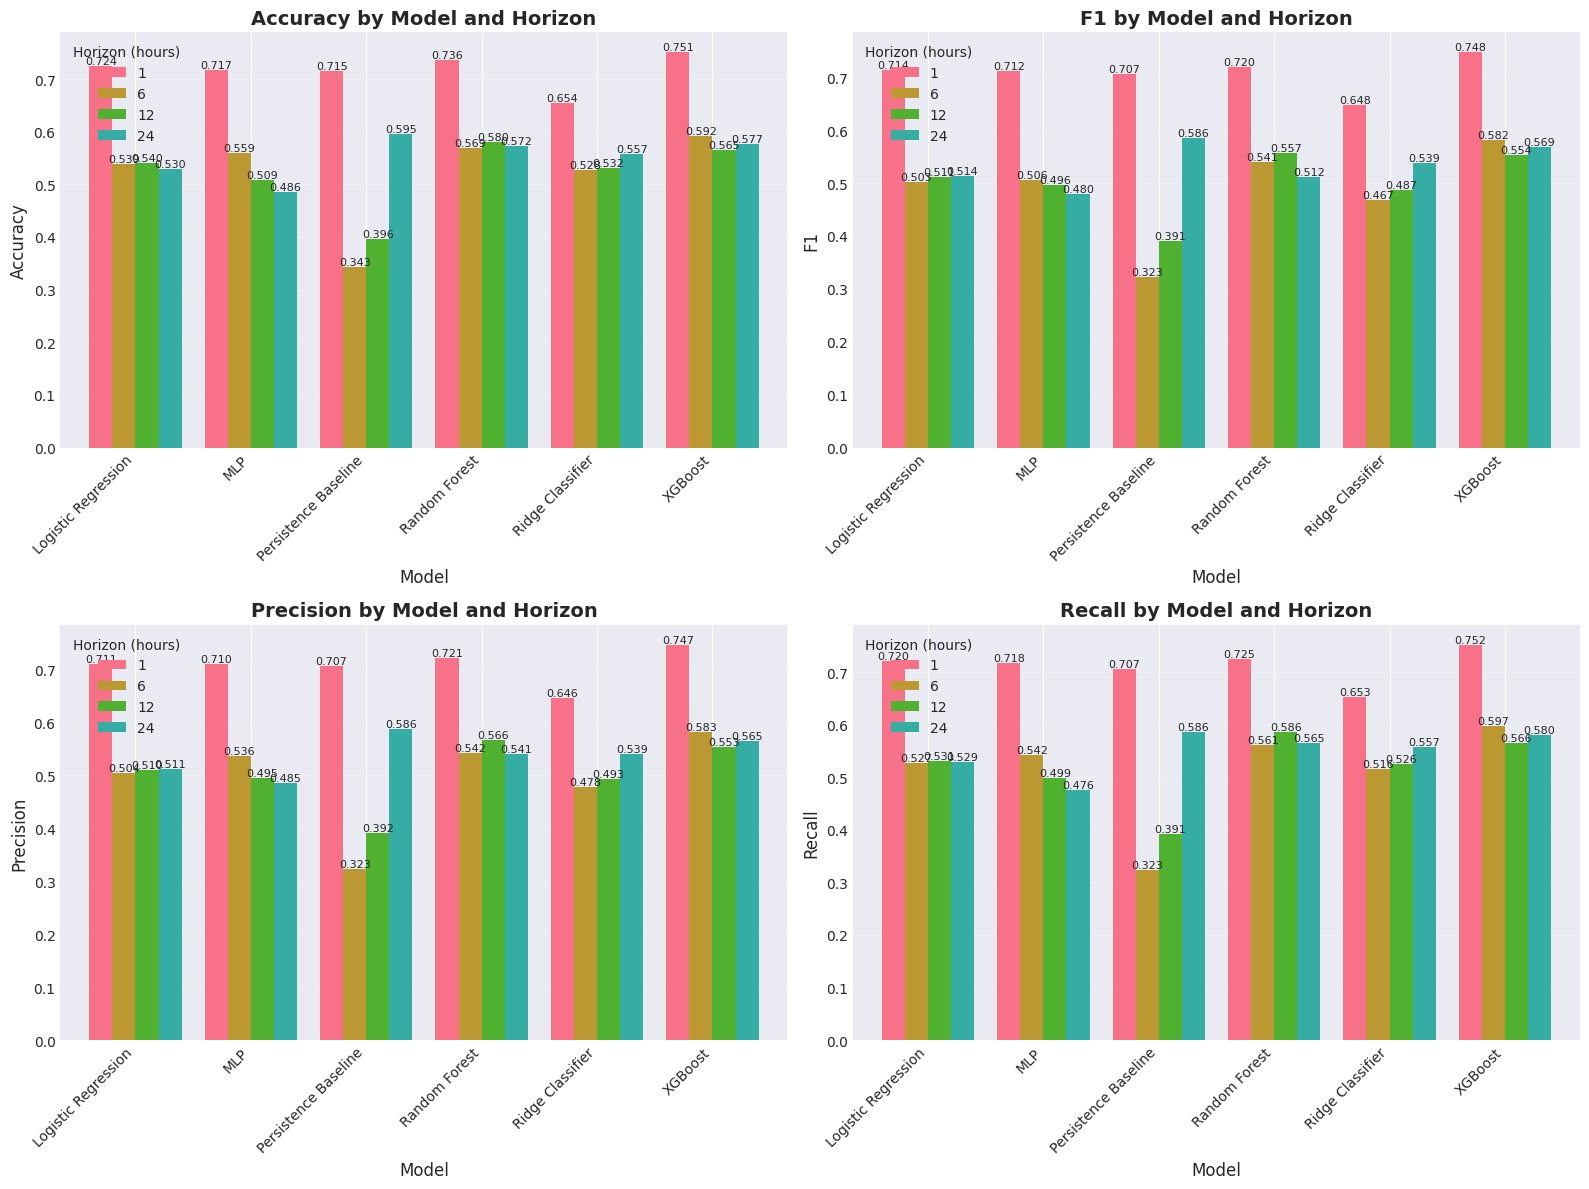

 Saved metrics comparison chart to /root/msy/COMP9417_GoodJob-main/classification-model/outputs/figures/performance/metrics_comparison_by_model_horizon.png


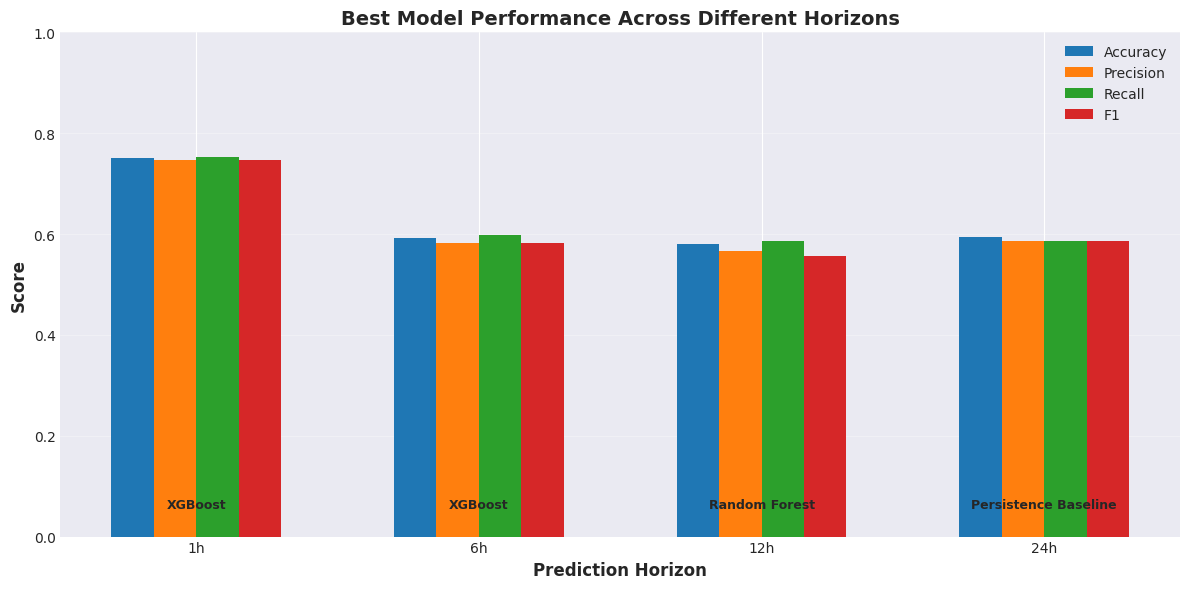

 Saved best models comparison to /root/msy/COMP9417_GoodJob-main/classification-model/outputs/figures/performance/best_models_across_horizons.png


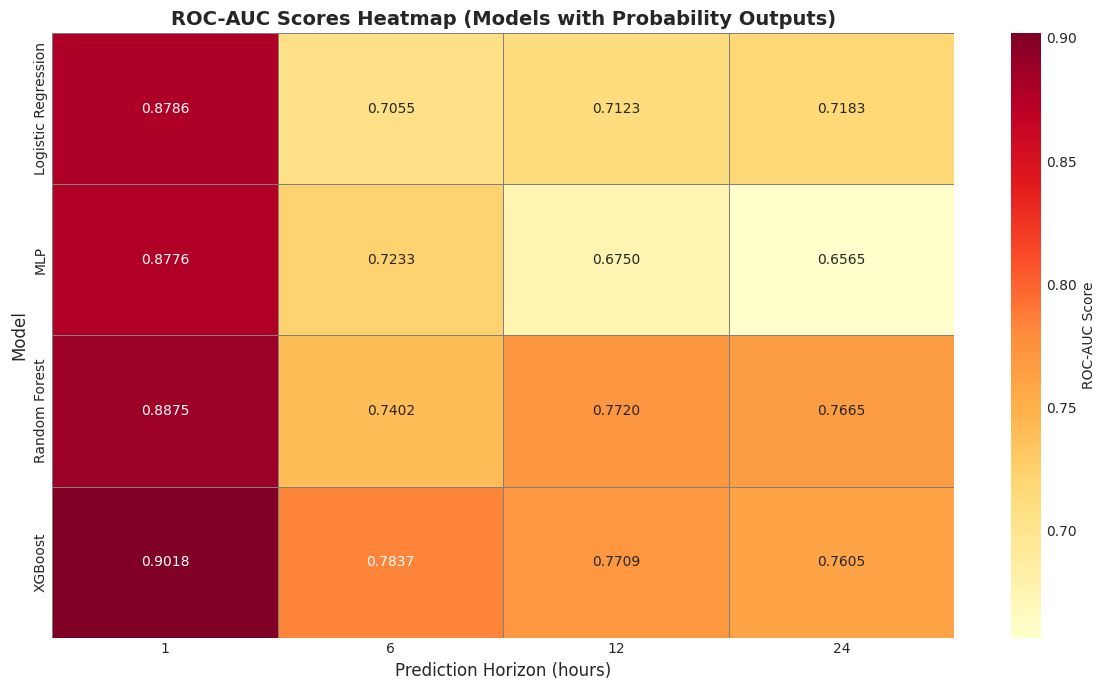

 Saved ROC-AUC heatmap to /root/msy/COMP9417_GoodJob-main/classification-model/outputs/figures/performance/roc_auc_heatmap.png


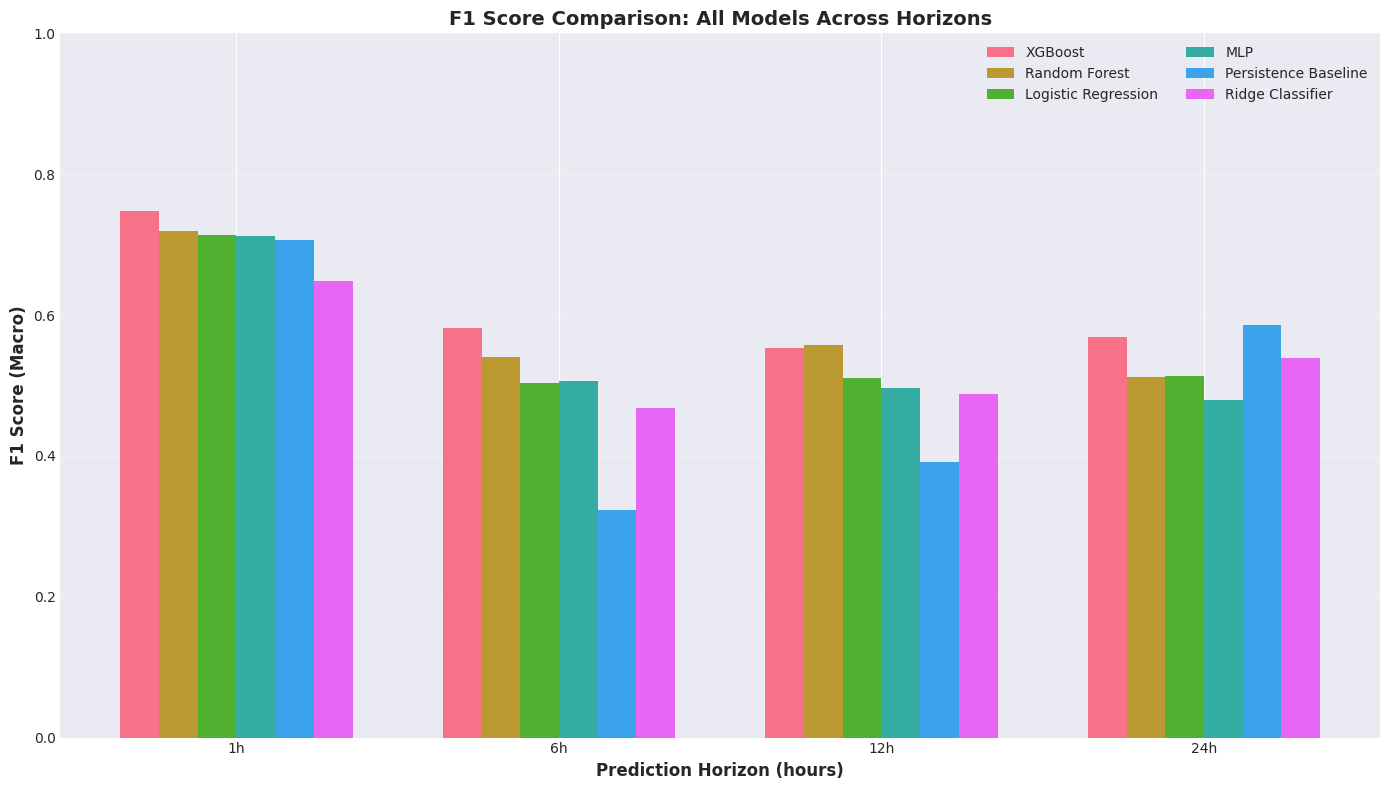

 Saved F1 score comparison to /root/msy/COMP9417_GoodJob-main/classification-model/outputs/figures/performance/f1_score_all_models.png


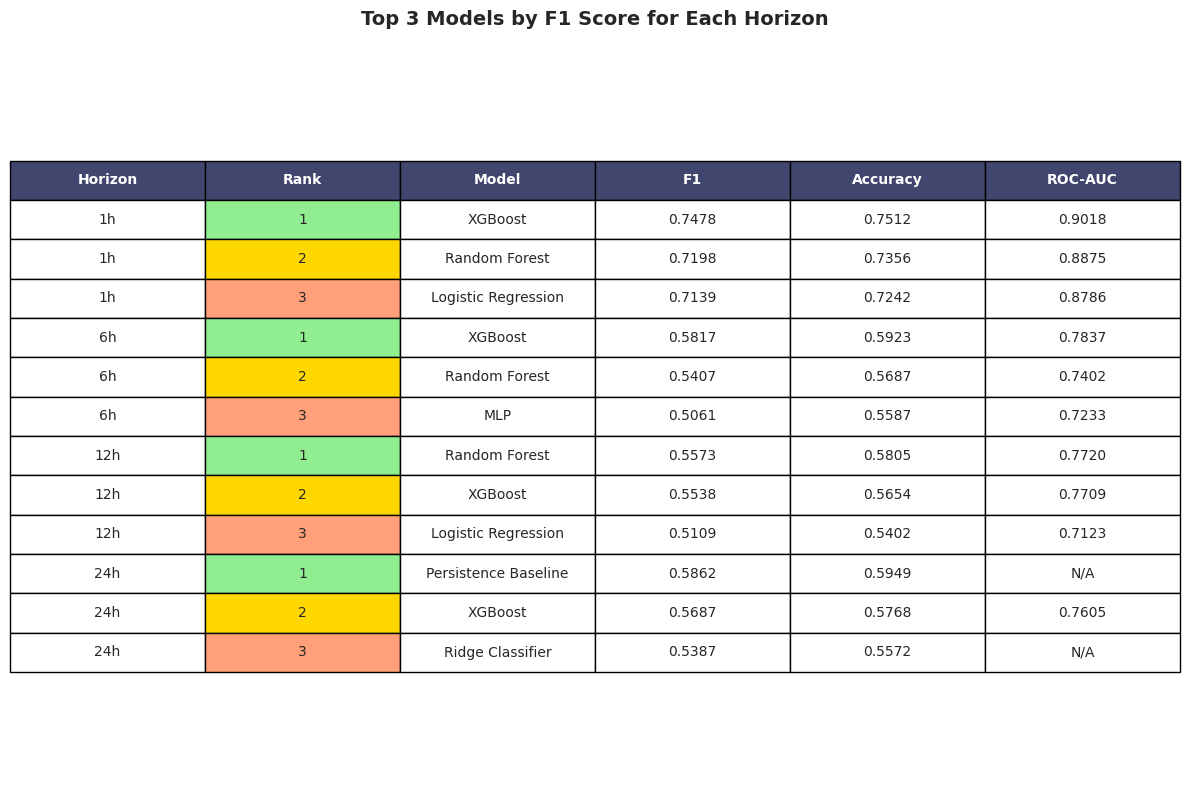

 Saved model ranking table to /root/msy/COMP9417_GoodJob-main/classification-model/outputs/figures/performance/model_ranking_table.png


In [48]:
# ======================================================
# Cell: Visualization - Model Performance Comparison Charts
# ======================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# ===== 1. Performance Metrics Comparison by Model and Horizon =====
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
metrics_to_plot = ['Accuracy', 'F1', 'Precision', 'Recall']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    # Prepare data for plotting
    plot_data = cls_results_df.pivot_table(
        index='model',
        columns='horizon_int',
        values=metric,
        aggfunc='mean'
    )
    
    # Create grouped bar chart
    plot_data.plot(kind='bar', ax=ax, width=0.8)
    ax.set_title(f'{metric} by Model and Horizon', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.legend(title='Horizon (hours)', loc='best')
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    

    for container in ax.containers:
        try:
            ax.bar_label(container, fmt='%.3f', fontsize=8)
        except AttributeError:
    
            pass

plt.tight_layout()
plt.savefig(PERFORMANCE_DIR / 'metrics_comparison_by_model_horizon.png', dpi=300, bbox_inches='tight')
plt.show()
print(' Saved metrics comparison chart to', PERFORMANCE_DIR / 'metrics_comparison_by_model_horizon.png')

# 2. Best Model Performance Across Horizons 
fig, ax = plt.subplots(figsize=(12, 6))

# Get best models per horizon
best_by_horizon = best_models.sort_values('horizon_int')

# Plot multiple metrics
x = np.arange(len(best_by_horizon))
width = 0.15

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    values = best_by_horizon[metric].values
    ax.bar(x + i * width, values, width, label=metric, color=color)

ax.set_xlabel('Prediction Horizon', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Best Model Performance Across Different Horizons', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"{h}h" for h in best_by_horizon['horizon_int']])
ax.legend(loc='best')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.0])

# Add model names as annotations
for i, (idx_row, row) in enumerate(best_by_horizon.iterrows()):
    ax.text(i + width * 1.5, 0.05, row['model'], 
            ha='center', va='bottom', fontsize=9, rotation=0, fontweight='bold')

plt.tight_layout()
plt.savefig(PERFORMANCE_DIR / 'best_models_across_horizons.png', dpi=300, bbox_inches='tight')
plt.show()
print(' Saved best models comparison to', PERFORMANCE_DIR / 'best_models_across_horizons.png')

# ===== 3. ROC-AUC Comparison (Models with probabilities only) =====
fig, ax = plt.subplots(figsize=(12, 7))

# Filter models with ROC-AUC scores (exclude NaN)
roc_data = cls_results_df[cls_results_df['ROC_AUC'].notna()].copy()

if not roc_data.empty:
    # Create pivot table
    roc_pivot = roc_data.pivot_table(
        index='model',
        columns='horizon_int',
        values='ROC_AUC',
        aggfunc='mean'
    )
    
    # Create heatmap
    sns.heatmap(roc_pivot, annot=True, fmt='.4f', cmap='YlOrRd', 
                cbar_kws={'label': 'ROC-AUC Score'}, ax=ax, 
                linewidths=0.5, linecolor='gray')
    ax.set_title('ROC-AUC Scores Heatmap (Models with Probability Outputs)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Prediction Horizon (hours)', fontsize=12)
    ax.set_ylabel('Model', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(PERFORMANCE_DIR / 'roc_auc_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(' Saved ROC-AUC heatmap to', PERFORMANCE_DIR / 'roc_auc_heatmap.png')
else:
    print(' No ROC-AUC data available for visualization')

# 4. F1 Score Comparison: All Models 
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data
f1_data = cls_results_df[['model', 'horizon', 'horizon_int', 'F1']].copy()
f1_data = f1_data.sort_values(['horizon_int', 'F1'], ascending=[True, False])

# Create grouped bar chart
models = f1_data['model'].unique()
horizons = sorted(f1_data['horizon_int'].unique())
x = np.arange(len(horizons))
width = 0.12

for i, model in enumerate(models):
    model_data = f1_data[f1_data['model'] == model]
    values = [
        model_data[model_data['horizon_int'] == h]['F1'].values[0] 
        if len(model_data[model_data['horizon_int'] == h]) > 0 
        else 0
        for h in horizons
    ]
    ax.bar(x + i * width, values, width, label=model)

ax.set_xlabel('Prediction Horizon (hours)', fontsize=12, fontweight='bold')
ax.set_ylabel('F1 Score (Macro)', fontsize=12, fontweight='bold')
ax.set_title('F1 Score Comparison: All Models Across Horizons', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels([f'{h}h' for h in horizons])
ax.legend(loc='best', ncol=2)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.0])

plt.tight_layout()
plt.savefig(PERFORMANCE_DIR / 'f1_score_all_models.png', dpi=300, bbox_inches='tight')
plt.show()
print(' Saved F1 score comparison to', PERFORMANCE_DIR / 'f1_score_all_models.png')

# ===== 5. Model Ranking Summary Table Visualization =====
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('tight')
ax.axis('off')

# Create ranking table
ranking_data = []
for horizon in sorted(cls_results_df['horizon_int'].unique()):
    horizon_data = cls_results_df[cls_results_df['horizon_int'] == horizon].sort_values(
        'F1', ascending=False, na_position='last'
    )
    for rank, (idx_row, row) in enumerate(horizon_data.head(3).iterrows(), 1):
        ranking_data.append({
            'Horizon': f"{horizon}h",
            'Rank': rank,
            'Model': row['model'],
            'F1': f"{row['F1']:.4f}",
            'Accuracy': f"{row['Accuracy']:.4f}",
            'ROC-AUC': f"{row['ROC_AUC']:.4f}" if not pd.isna(row['ROC_AUC']) else 'N/A'
        })

ranking_df = pd.DataFrame(ranking_data)

# Create table
table = ax.table(
    cellText=ranking_df.values,
    colLabels=ranking_df.columns,
    cellLoc='center',
    loc='center',
    colColours=['#40466e'] * len(ranking_df.columns)
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header
for i in range(len(ranking_df.columns)):
    cell = table[(0, i)]
    cell.set_text_props(weight='bold', color='white')

# Color code ranks
for i in range(1, len(ranking_df) + 1):
    rank = int(ranking_df.iloc[i - 1]['Rank'])
    if rank == 1:
        table[(i, 1)].set_facecolor('#90EE90')
    elif rank == 2:
        table[(i, 1)].set_facecolor('#FFD700')
    elif rank == 3:
        table[(i, 1)].set_facecolor('#FFA07A')

ax.set_title(
    'Top 3 Models by F1 Score for Each Horizon',
    fontsize=14, fontweight='bold', pad=20
)

plt.tight_layout()
plt.savefig(PERFORMANCE_DIR / 'model_ranking_table.png', dpi=300, bbox_inches='tight')
plt.show()
print(' Saved model ranking table to', PERFORMANCE_DIR / 'model_ranking_table.png')

